# Olist Brazilian E-Commerce — Exploratory Data Analysis

The Olist dataset covers 99,441 orders placed on a Brazilian marketplace between September
2016 and October 2018, spread across nine related tables. Olist connects small sellers to
larger platforms and handles their logistics for them, so a single order can involve several
sellers and arrive in separate shipments. That detail shapes how the tables fit together, and
most of the join work in Section 4 exists because of it.

This is Phase 1, so the aim is to understand the data and work out what might be worth
modelling later, not to model anything yet. We kept the exploration wide rather than steering
it toward a particular question; the candidate problems that came out of it are gathered and
assessed together in Section 8.


The analysis runs on two tables built in Section 4. 

`order_level` holds one row per order,
with the child tables aggregated or deduplicated down to that grain before they are joined on.

`item_level` stays at one row per order item, because product and category questions need the
individual line. Every join is checked afterwards to confirm the row count did not move and
the key is still unique.

A few terms come up repeatedly:

| Term | Definition |
|---|---|
| `delivery_days` | Calendar days from the purchase date to the delivery date |
| `estimated_delivery_days` | Calendar days from the purchase date to the date quoted at checkout |
| `days_early` | Quoted delivery date minus the date the order arrived, in whole days. Positive means it came early, 0 means it came on the promised day, negative means late
| `late_delivery_flag` | 1 when the order arrived after the promised date, 0 when it arrived on or before it, `NaN` when it was never delivered |
| `is_delivered_complete` | Status is `delivered` *and* a delivery timestamp exists — the population behind every delivery figure in this notebook |
| GMV | Sum of item prices, excluding freight. Not Olist's own revenue |
| R$ | Brazilian Real |


## 1. Setup and Data Loading


In [2]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


from itertools import combinations

DATA_DIR = Path.cwd()
n_found = len(list(DATA_DIR.glob("olist_*.csv"))) + len(list(DATA_DIR.glob("product_category*.csv")))
assert n_found == 9, f"expected 9 Olist CSVs in {DATA_DIR}, found {n_found}"

RANDOM_SEED = 42          # used by the 8,000-row scatter sample in Section 7

# House chart style, set once so no figure cell has to repeat it.
BLUE, AMBER, GREEN = "#2563eb", "#d97706", "#059669"
plt.rcParams.update({
    "figure.autolayout":  True,       # was plt.tight_layout(), 13 cells
    "axes.spines.top":    False,      # was the spines line, 12 cells
    "axes.spines.right":  False,
    "axes.grid":          True,       # was ax.grid(alpha=0.25), 11 cells
    "axes.grid.axis":     "y",
    "grid.alpha":         0.25,
    "axes.titlelocation": "left",     # was loc="left" on every set_title
    "axes.prop_cycle":    plt.cycler(color=[BLUE, AMBER, GREEN]),
})


In [3]:
# Timestamps are parsed at load time, so no duration is ever computed from a string.
# Note: order_estimated_delivery_date is a pure date (always midnight) while every other
# timestamp carries a time of day. Section 4 normalises both sides to dates before
# differencing them - mixing the two silently floors a same-day difference to -1.


orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
                 "order_delivered_customer_date", "order_estimated_delivery_date"],
)
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv",
                          parse_dates=["shipping_limit_date"])
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv",
                      parse_dates=["review_creation_date", "review_answer_timestamp"])

payments             = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
customers            = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
sellers              = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
products             = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
geolocation          = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

TABLES = {"orders": orders, 
          "order_items": order_items, 
          "payments": payments,
          "reviews": reviews, 
          "customers": customers, 
          "sellers": sellers,
          "products": products, 
          "geolocation": geolocation,
          "category_translation": category_translation}

for name, df in TABLES.items():
    n_dt = df.select_dtypes("datetime").shape[1]
    print(f"{name:22s} {df.shape[0]:>9,} rows x {df.shape[1]:>2} cols   {n_dt} datetime")



orders                    99,441 rows x  8 cols   5 datetime
order_items              112,650 rows x  7 cols   1 datetime
payments                 103,886 rows x  5 cols   0 datetime
reviews                   99,224 rows x  7 cols   2 datetime
customers                 99,441 rows x  5 cols   0 datetime
sellers                    3,095 rows x  4 cols   0 datetime
products                  32,951 rows x  9 cols   0 datetime
geolocation            1,000,163 rows x  5 cols   0 datetime
category_translation          71 rows x  2 cols   0 datetime


In [4]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


In [5]:
# Full collection range. Section 5 shows the usable window is narrower - 2016 is near-empty.
span = orders["order_purchase_timestamp"].agg(["min", "max"])
print(f"First order: {span['min']:%Y-%m-%d}")
print(f"Last order:  {span['max']:%Y-%m-%d}")
print(f"Span:        {(span['max'] - span['min']).days} days")

First order: 2016-09-04
Last order:  2018-10-17
Span:        772 days


## 2. Dataset Overview

### Primary keys

Rather than assume a key from the column names, we derive one. Every 1 and 2 column
combination is tested, and any combination that is both non-null and duplicate-free counts
as a valid candidate. The search stops at the smallest size that finds anything, so a table
with a single-column key never reports pairs on top of it.

Two columns is the ceiling, which means a table genuinely needing a three-column key would
report nothing at all. Only `geolocation` comes back empty, and that turns out not to be a
limit of the search — it is keyless by nature, carrying 261,831 exact duplicate rows.


In [6]:
# Test every 1 and 2 column combination; a candidate key is non-null and duplicate-free.


def find_candidate_keys(df, max_key_size=2):
    for size in range(1, max_key_size + 1):
        found = [cols for cols in combinations(df.columns, size)
                 if not df[list(cols)].isna().any(axis=1).any()
                 and not df.duplicated(subset=list(cols)).any()]
        if found:
            return found
    return []

key_rows = []
for name, df in TABLES.items():
    keys = find_candidate_keys(df)
    if keys:
        key_rows += [{"table": name, "candidate_key": " + ".join(k), "rows": len(df)} for k in keys]
    else:
        key_rows.append({"table": name, "candidate_key": "none", "rows": len(df),
                         "exact_duplicate_rows": df.duplicated().sum()})

key_report = pd.DataFrame(key_rows)
key_report


,table,candidate_key,rows,exact_duplicate_rows
0,orders,order_id,99441,NaN
1,orders,customer_id,99441,NaN
2,order_items,order_id + order_item_id,112650,NaN
3,payments,order_id + payment_sequential,103886,NaN
4,reviews,review_id + order_id,99224,NaN
5,reviews,order_id + review_answer_timestamp,99224,NaN
6,customers,customer_id,99441,NaN
7,sellers,seller_id,3095,NaN
8,products,product_id,32951,NaN
9,geolocation,none,1000163,261831.0


In [7]:
# Resolve the primary key for every table. find_candidate_keys returns EVERY valid
# combination, so three tables come back with two candidates and the choice between them
# is a judgement, not a computation - the reasoning is in the markdown below. Every
# declared key is re-verified here, so this cell cannot drift from key_report.

CONFIRMED_PRIMARY_KEYS = {
    "orders":               ["order_id"],
    "order_items":          ["order_id", "order_item_id"],
    "payments":             ["order_id", "payment_sequential"],
    "reviews":              ["review_id", "order_id"],
    "customers":            ["customer_id"],
    "sellers":              ["seller_id"],
    "products":             ["product_id"],
    "geolocation":          None,
    "category_translation": ["product_category_name"],
}

n_candidates = key_report[key_report["candidate_key"] != "none"].groupby("table").size()

rows = []
for name, key in CONFIRMED_PRIMARY_KEYS.items():
    if key is not None:
        assert not TABLES[name][key].isna().any(axis=1).any(), f"{name}: {key} has nulls"
        assert not TABLES[name].duplicated(subset=key).any(),  f"{name}: {key} not unique"
    rows.append({"table":       name,
                 "candidates":  int(n_candidates.get(name, 0)),
                 "selected_primary_key": " + ".join(key) if key else "none"})

primary_keys = pd.DataFrame(rows)
primary_keys.style.hide(axis="index")


table,candidates,selected_primary_key
orders,2,order_id
order_items,1,order_id + order_item_id
payments,1,order_id + payment_sequential
reviews,2,review_id + order_id
customers,1,customer_id
sellers,1,seller_id
products,1,product_id
geolocation,0,none
category_translation,2,product_category_name


Three tables offered more than one valid key, so the choice was a judgement rather than a
computation:

- **orders** — `customer_id` is unique here too, but it is issued once per purchase, so it
  identifies the transaction rather than the customer. `order_id` is what a row actually is.

- **reviews** — `(order_id, review_answer_timestamp)` is also unique, but a timestamp that
  fine-grained is distinct by chance rather than by design. `(review_id, order_id)` is the
  key the table was built around.

- **category_translation** — both columns are unique. `product_category_name` is the one that
  also appears in `products`, so it is the usable join key.
  
- **geolocation** has no key at all: 261,831 of its rows are exact duplicates. It is excluded
  from every merge in Section 4.


### Foreign keys

In [8]:
# Map every column name to the tables it appears in. Shared names are the join routes
# between tables - the foreign keys in the markdown below are read straight off this.
column_tables = {}
for name, df in TABLES.items():
    for col in df.columns:
        column_tables.setdefault(col, []).append(name)

shared_columns = {col: tbls for col, tbls in column_tables.items() if len(tbls) > 1}

for col, tbls in sorted(shared_columns.items()):
    print(f"{col:28s} -> {', '.join(tbls)}")


customer_id                  -> orders, customers
order_id                     -> orders, order_items, payments, reviews
product_category_name        -> products, category_translation
product_id                   -> order_items, products
seller_id                    -> order_items, sellers


The shared-column map above gives the links between tables:

| Table | Foreign keys |
|---|---|
| orders | `customer_id` → customers |
| order_items | `order_id` → orders, `product_id` → products, `seller_id` → sellers |
| payments | `order_id` → orders |
| reviews | `order_id` → orders |
| products | `product_category_name` → category_translation |

Matching on exact column names finds these five links but misses one. The only route into
`geolocation` is the zip code prefix, which travels under three different names —
`customer_zip_code_prefix`, `seller_zip_code_prefix` and `geolocation_zip_code_prefix` —
and 99% of customer and seller prefixes do have a match there, so it is a real join, just
not one this method can see. It costs us nothing in practice, because `geolocation` has no
primary key and 261,831 duplicate rows and is excluded from every merge, but the map is not
exhaustive and shouldn't be read as one.


### Table summary

In [9]:
# Primary keys come from the decision cell above; date columns are read from the parsed
# dtypes rather than restated, so this table cannot disagree with what actually loaded.
rows = []
for name, df in TABLES.items():
    pk = CONFIRMED_PRIMARY_KEYS[name]
    missing = int(df.isna().sum().sum())
    rows.append({"table":          name,
                 "rows":           df.shape[0],
                 "cols":           df.shape[1],
                 "primary_key":    " + ".join(pk) if pk else "none (needs dedup)",
                 "date_cols":      df.select_dtypes("datetime").shape[1],
                 "missing_cells":  missing,
                 "missing_pct":    100 * missing / df.size,
                 "duplicate_rows": int(df.duplicated().sum())})

overview = pd.DataFrame(rows)
overview.style.format({"rows": "{:,}", "missing_cells": "{:,}",
                       "duplicate_rows": "{:,}", "missing_pct": "{:.2f}"}).hide(axis="index")



table,rows,cols,primary_key,date_cols,missing_cells,missing_pct,duplicate_rows
orders,"99,441",8,order_id,5,"4,908",0.62,0
order_items,"112,650",7,order_id + order_item_id,1,0,0.00,0
payments,"103,886",5,order_id + payment_sequential,0,0,0.00,0
reviews,"99,224",7,review_id + order_id,2,"145,903",21.01,0
customers,"99,441",5,customer_id,0,0,0.00,0
sellers,"3,095",4,seller_id,0,0,0.00,0
products,"32,951",9,product_id,0,"2,448",0.83,0
geolocation,"1,000,163",5,none (needs dedup),0,0,0.00,"261,831"
category_translation,71,2,product_category_name,0,0,0.00,0


In [10]:
# Where the missing cells actually sit. Only three of the nine tables have any.
for name in ["reviews", "orders", "products"]:
    df = TABLES[name]
    total = int(df.isna().sum().sum())
    per_col = df.isna().sum()
    per_col = per_col[per_col > 0].sort_values(ascending=False)
    print(f"{name}  -  {total:,} missing cells ({100*total/df.size:.2f}%)")
    for col, n in per_col.items():
        print(f"    {col:32s} {n:>7,}  ({100*n/len(df):5.1f}% of rows)")
    print()

# Are the missing delivery dates explained by orders that never completed?
print("orders with no delivery date, by status:")
print(orders.loc[orders["order_delivered_customer_date"].isna(), "order_status"]
      .value_counts().to_string())


reviews  -  145,903 missing cells (21.01%)
    review_comment_title              87,656  ( 88.3% of rows)
    review_comment_message            58,247  ( 58.7% of rows)

orders  -  4,908 missing cells (0.62%)
    order_delivered_customer_date      2,965  (  3.0% of rows)
    order_delivered_carrier_date       1,783  (  1.8% of rows)
    order_approved_at                    160  (  0.2% of rows)

products  -  2,448 missing cells (0.83%)
    product_category_name                610  (  1.9% of rows)
    product_name_lenght                  610  (  1.9% of rows)
    product_description_lenght           610  (  1.9% of rows)
    product_photos_qty                   610  (  1.9% of rows)
    product_weight_g                       2  (  0.0% of rows)
    product_length_cm                      2  (  0.0% of rows)
    product_height_cm                      2  (  0.0% of rows)
    product_width_cm                       2  (  0.0% of rows)

orders with no delivery date, by status:
order_status
s

Missing values are concentrated in three tables, and in each case the gap is structural
rather than a fault in the data.

In `reviews`, all 21% sits in two optional free-text columns — `review_comment_title` is
absent for 88.3% of reviews and `review_comment_message` for 58.7%. The scores themselves are
complete, which is what matters here. The text is also in Portuguese, and Section 8 rules it
out of scope for both reasons.

In `orders`, the 0.62% is entirely delivery timestamps: 2,965 orders have no delivery date,
1,783 no carrier date, 160 no approval date. These are overwhelmingly orders that never
completed — 1,107 `shipped`, 619 `canceled`, 609 `unavailable`, and the rest still in
processing. Eight are marked `delivered` yet carry no delivery date at all, a contradiction
Section 3 picks up and Section 4 excludes.

`products` has two separate gaps. 610 rows are missing their category name and three
description fields together, which is a clean block rather than scattered nulls, and two rows
are missing all four physical dimensions.

Nothing is imputed here. Missing values are kept as nulls so every count downstream stays
reconcilable with the source tables.


## 3. Data Quality Checks

In [11]:
# Every check below records one row here. The summary at the end of Section 3 renders from
# this list rather than being retyped, so it cannot drift from what was measured.
quality_checks = []

def record(n, check, result, status, action="none needed"):
    quality_checks[:] = [r for r in quality_checks if r["#"] != n]   # re-running replaces
    quality_checks.append({"#": n, "check": check, "result": result,
                           "status": status, "action": action})
    quality_checks.sort(key=lambda r: r["#"])


### Check 1 — prices, freight and payments non-negative

Prices, freight charges and payment values must never be negative.


In [12]:
value_cols = [("order_items.price",         order_items, "price"),
              ("order_items.freight_value", order_items, "freight_value"),
              ("payments.payment_value",    payments,    "payment_value")]

detail = pd.DataFrame([{"column":     label,
                        "min_value":  df[col].min(),
                        "violations": int((df[col] < 0).sum())}
                       for label, df, col in value_cols])

n_bad = int(detail["violations"].sum())
record(1, "Prices, freight and payments non-negative",
       f"{n_bad} violations across order_items.price, freight_value and payments.payment_value",
       "PASS" if n_bad == 0 else "FAIL")

display(detail.style.hide(axis="index"))


column,min_value,violations
order_items.price,0.850000,0
order_items.freight_value,0.000000,0
payments.payment_value,0.000000,0


### Check 2 — review scores within 1-5

Every review score must fall in the range 1 to 5. Nulls count as violations, since
`between()` returns False for them.


In [13]:
scores = reviews["review_score"]
n_bad = int((~scores.between(1, 5)).sum())     # NaN fails between(), so nulls count here too

print(f"reviews: {len(reviews):,} rows")
print(f"violations (outside 1-5, nulls included): {n_bad}")

record(2, "Review scores within 1-5",
       f"{n_bad} violations across {len(reviews):,} rows, nulls counted as violations",
       "PASS" if n_bad == 0 else "FAIL")

dist = scores.value_counts().sort_index().reset_index()
dist["pct"] = 100 * dist["count"] / dist["count"].sum()
display(dist.style.format({"count": "{:,}", "pct": "{:.2f}"}).hide(axis="index"))



reviews: 99,224 rows
violations (outside 1-5, nulls included): 0


review_score,count,pct
1,"11,424",11.51
2,"3,151",3.18
3,"8,179",8.24
4,"19,142",19.29
5,"57,328",57.78


### Check 3 — delivery date after purchase date

A delivery date must not precede its purchase date. Cross-checked against the opposite
error — orders marked `delivered` that carry no delivery date at all.


In [14]:
delivered = orders[orders["order_delivered_customer_date"].notna()]
n_bad = int((delivered["order_delivered_customer_date"] < delivered["order_purchase_timestamp"]).sum())

# Cross-check: orders marked delivered that carry no delivery date at all.
no_date = orders[(orders["order_status"] == "delivered")
                 & orders["order_delivered_customer_date"].isna()]

print(f"orders with a delivery date:              {len(delivered):>7,}")
print(f"delivered before purchase:                {n_bad:>7}")
print()
n_carrier = int(no_date["order_delivered_carrier_date"].notna().sum())
print(f"marked 'delivered' with no delivery date: {len(no_date):>7}")
print(f"   reached a carrier:                     {n_carrier:>7}")
print(f"   no shipping evidence at all:           {len(no_date) - n_carrier:>7}")

print("\nBelowthe eight orders - the one with no shipping evidence shows NaT:")
no_date[["order_id", "order_purchase_timestamp", "order_approved_at",
         "order_delivered_carrier_date"]]



record(3, "Delivery date after purchase date",
       f"{n_bad} orders delivered before purchase; {len(no_date)} marked 'delivered' with no delivery date",
       "PASS" if n_bad == 0 else "FAIL",
       "the no-date orders are excluded from delivery analysis by is_delivered_complete (Section 4)")

display(no_date[["order_id", "order_status", "order_purchase_timestamp",
         "order_approved_at", "order_delivered_carrier_date"]].style.hide(axis="index"))


orders with a delivery date:               96,476
delivered before purchase:                      0

marked 'delivered' with no delivery date:       8
   reached a carrier:                           7
   no shipping evidence at all:                 1

Belowthe eight orders - the one with no shipping evidence shows NaT:


order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date
2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23
f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00
2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00
e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00
0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00
2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT
ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00
20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00


### Check 4 — estimated delivery date after purchase date

The date quoted at checkout must fall after the purchase. Both sides are normalised to
calendar dates first, matching the convention Section 4 uses for all day counts.


In [15]:
# Both sides normalised to dates, matching the day-count convention used in Section 4.
lead_days = (orders["order_estimated_delivery_date"]
             - orders["order_purchase_timestamp"].dt.normalize()).dt.days
n_bad = int((lead_days < 0).sum())

print(f"estimated delivery before purchase: {n_bad}")
print(f"quoted lead time (calendar days):   min {lead_days.min()}, "
      f"median {int(lead_days.median())}, max {lead_days.max()}")

record(4, "Estimated delivery date after purchase date",
       f"{n_bad} violations; quoted lead time runs from {lead_days.min()} to {lead_days.max()} days",
       "PASS" if n_bad == 0 else "FAIL")


estimated delivery before purchase: 0
quoted lead time (calendar days):   min 2, median 24, max 156


### Check 5 — order status values

In [16]:
status_table = orders["order_status"].value_counts(dropna=False).reset_index()
status_table["pct"] = 100 * status_table["count"] / status_table["count"].sum()
display(status_table.style.format({"count": "{:,}", "pct": "{:.2f}"}).hide(axis="index"))


print(f"{len(status_table)} distinct values, summing to {status_table['count'].sum():,}, "
      f"with {orders['order_status'].isna().sum()} nulls")

# The mirror image of Check 3: a delivery date under a status other than 'delivered'.
date_not_delivered = orders[(orders["order_status"] != "delivered")
                            & orders["order_delivered_customer_date"].notna()]
breakdown = ", ".join(f"{n} {s}" for s, n in
                      date_not_delivered["order_status"].value_counts().items())
print(f"delivery date under a non-'delivered' status: {len(date_not_delivered)}  ({breakdown})")

record(5, "Order status in known value set",
       f"{len(status_table)} distinct values, all plausible lifecycle stages, no nulls; "
       f"separately, {len(date_not_delivered)} orders carry a delivery date under another status",
       "PASS",
       "both contradictions resolved in Section 4 by is_delivered_complete, which requires "
       "status 'delivered' AND a delivery timestamp")


order_status,count,pct
delivered,"96,478",97.02
shipped,"1,107",1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


8 distinct values, summing to 99,441, with 0 nulls
delivery date under a non-'delivered' status: 6  (6 canceled)


All eight values are plausible lifecycle stages, with no typos, no nulls, and counts summing
to exactly 99,441.

Cross-checking against Check 3 turns up the mirror-image error. 96,478 orders carry the status
`delivered`, but only 96,476 have a delivery date. Subtract the eight `delivered` orders that
have no date and you are left with six that have a date under a different status — and all six
are `canceled`, which reads as orders cancelled after they had already shipped.

Both contradictions get the same treatment in Section 4. `is_delivered_complete` requires the
status and the timestamp to agree, so the eight and the six are excluded together.


### Check 6 — product dimensions and weight positive

Weight, length, height and width must all be present and greater than zero.


In [17]:
dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]

dim_summary = pd.DataFrame([{"column":      c,
                             "nulls":       int(products[c].isna().sum()),
                             "nonpositive": int((products[c] <= 0).sum())}
                            for c in dim_cols])
display(dim_summary.style.hide(axis="index"))

null_mask  = products[dim_cols].isna().any(axis=1)
bad_weight = products["product_weight_g"] <= 0
all_four   = bool(products.loc[null_mask, dim_cols].isna().all(axis=1).all())

print(f"missing at least one dimension: {int(null_mask.sum())}  "
      f"(all four missing together: {all_four})")
display(products.loc[null_mask, ["product_id", "product_category_name"] + dim_cols]
        .style.format(na_rep="-").hide(axis="index"))

n_bad = int(bad_weight.sum())
print(f"weight <= 0: {n_bad}")
display(products.loc[bad_weight, ["product_id", "product_category_name"] + dim_cols]
        .style.format(precision=0).hide(axis="index"))

record(6, "Product dimensions and weight positive",
       f"{int(null_mask.sum())} products missing all four dimensions together; "
       f"{n_bad} products with weight <= 0",
       "PASS" if n_bad == 0 else f"FAIL - {n_bad} weight violations",
       "null product_weight_g for the affected rows, keep the rows (Section 4)")


column,nulls,nonpositive
product_weight_g,2,4
product_length_cm,2,0
product_height_cm,2,0
product_width_cm,2,0


missing at least one dimension: 2  (all four missing together: True)


product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
09ff539a621711667c43eba6a3bd8466,bebes,-,-,-,-
5eb564652db742ff8f28759cd8d2652a,-,-,-,-,-


weight <= 0: 4


product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,0,30,25,30
8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,0,30,25,30
36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,0,30,25,30
e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,0,30,25,30


The two gaps are different in kind. Two products have no measurements at all — all four
fields missing together, which reads as a record that was never completed rather than a
corrupted one. Separately, four products carry a weight of exactly zero while holding
plausible dimensions, and all four are `cama_mesa_banho` with identical 30×25×30 measurements,
which looks like a template row saved without its weight.

Zero grams is impossible for a physical product, so those four weights are set to null in
Section 4. The rows themselves are kept — the products were really sold, and only the weight
is untrustworthy.

### Check 7 — Duplicate primary keys

Every key declared in Section 2 must still be unique here. `geolocation` has no key, so it is
checked for exact duplicate rows instead.


In [18]:
pk_rows = []
for name, key in CONFIRMED_PRIMARY_KEYS.items():
    df = TABLES[name]
    pk_rows.append({"table":          name,
                    "key":            " + ".join(key) if key else "none",
                    "duplicate_rows": int(df.duplicated(subset=key).sum()) if key
                                      else int(df.duplicated().sum())})

pk_check  = pd.DataFrame(pk_rows)
display(pk_check.style.format({"duplicate_rows": "{:,}"}).hide(axis="index"))

n_bad     = int(pk_check.loc[pk_check["key"] != "none", "duplicate_rows"].sum())
geo_dupes = int(pk_check.loc[pk_check["key"] == "none", "duplicate_rows"].iloc[0])

record(7, "Duplicate primary keys where uniqueness expected",
       f"{n_bad} duplicates across the eight keyed tables; geolocation has no key and "
       f"{geo_dupes:,} exact duplicate rows",
       "PASS" if n_bad == 0 else "FAIL",
       "geolocation is excluded from every merge in Section 4; deduplicate before any use")


table,key,duplicate_rows
orders,order_id,0
order_items,order_id + order_item_id,0
payments,order_id + payment_sequential,0
reviews,review_id + order_id,0
customers,customer_id,0
sellers,seller_id,0
products,product_id,0
geolocation,none,"261,831"
category_translation,product_category_name,0


### Check 8 — order lifecycle timestamps in sequence

The four timestamps should run in order: purchase, then payment approval, then carrier pickup,
then delivery. Each pair is checked over the orders where both timestamps are present.

### Lifecycle order should run purchase -> approved -> carrier -> delivered.




In [19]:
# The four timestamps define a lifecycle; STAGES holds both its order and the short
# names used in the table below, so the two cannot drift apart.
STAGES = {
    "order_purchase_timestamp":      "purchase",
    "order_approved_at":             "approved",
    "order_delivered_carrier_date":  "carrier",
    "order_delivered_customer_date": "delivered",
}

print("Each rule compares one pair of timestamps, over the orders where both are present.")

sequence_rules = [
    ("order_approved_at",             "order_purchase_timestamp",     "adjacent"),
    ("order_delivered_carrier_date",  "order_approved_at",            "adjacent"),
    ("order_delivered_customer_date", "order_delivered_carrier_date", "adjacent"),
    ("order_delivered_carrier_date",  "order_purchase_timestamp",     "alternative"),
]

seq_rows = []
for later, earlier, kind in sequence_rules:
    both = orders[later].notna() & orders[earlier].notna()
    bad  = int((orders.loc[both, later] < orders.loc[both, earlier]).sum())
    seq_rows.append({"rule":       f"{STAGES[later]} >= {STAGES[earlier]}",
                     "type":       kind,
                     "comparable": int(both.sum()),
                     "violations": bad,
                     "pct":        100 * bad / both.sum()})

seq = pd.DataFrame(seq_rows)
display(seq.style.format({"comparable": "{:,}", "violations": "{:,}", "pct": "{:.2f}"})
        .hide(axis="index"))

# The single worst carrier date, to show these are not rounding artefacts.
gap = orders["order_delivered_carrier_date"] - orders["order_purchase_timestamp"]
print(f"worst carrier date predates its own order by {-gap.min().days} days:")
display(orders.loc[[gap.idxmin()],
                   ["order_id", "order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date"]]
        .style.hide(axis="index"))

n_ca = int(seq.loc[seq["rule"] == "carrier >= approved",  "violations"].iloc[0])
n_cp = int(seq.loc[seq["rule"] == "carrier >= purchase",  "violations"].iloc[0])
n_dc = int(seq.loc[seq["rule"] == "delivered >= carrier", "violations"].iloc[0])

record(8, "Order lifecycle timestamps in sequence",
       f"{n_ca:,} orders have a carrier date before approval and {n_dc} a delivery before the "
       f"carrier date; measuring handling from purchase instead of approval removes "
       f"{n_ca - n_cp:,}, leaving {n_cp + n_dc} impossible under any definition",
       "FAIL",
       f"Section 7 measures seller handling as purchase->carrier and excludes the remaining "
       f"{n_cp + n_dc} rows from stage analysis")


Each rule compares one pair of timestamps, over the orders where both are present.


rule,type,comparable,violations,pct
approved >= purchase,adjacent,"99,281",0,0.00
carrier >= approved,adjacent,"97,644","1,359",1.39
delivered >= carrier,adjacent,"96,475",23,0.02
carrier >= purchase,alternative,"97,658",166,0.17


worst carrier date predates its own order by 172 days:


order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
7c48bb55e8e4f7e56d412e9653db37bc,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45


This is the one check that fails. 1,359 orders (1.39%) show the carrier collecting the parcel
before the payment was approved, and 23 show delivery before collection.

The two have different causes. Approval timestamps appear to be written in batches, sometimes
days after the parcel has already moved, which makes approval an unreliable start point rather
than a wrong one. A smaller group is genuinely corrupt: the worst carrier date sits 172 days
before the order that produced it.

Measuring seller handling from purchase rather than approval sidesteps the first cause and
removes 1,193 of the 1,359. The remaining 166, plus the 23 out-of-order deliveries, are
impossible under any definition and are excluded from the stage analysis in Section 7. That
is 189 orders, 0.19% of the table, so medians are unaffected.


In [20]:
quality_summary = pd.DataFrame(quality_checks)
assert len(quality_summary) == 8, f"expected 8 checks, recorded {len(quality_summary)}"

display(quality_summary.style
        .hide(axis="index")
        .set_properties(**{"text-align": "left", "vertical-align": "top",
                           "white-space": "normal"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


#,check,result,status,action
1,"Prices, freight and payments non-negative","0 violations across order_items.price, freight_value and payments.payment_value",PASS,none needed
2,Review scores within 1-5,"0 violations across 99,224 rows, nulls counted as violations",PASS,none needed
3,Delivery date after purchase date,0 orders delivered before purchase; 8 marked 'delivered' with no delivery date,PASS,the no-date orders are excluded from delivery analysis by is_delivered_complete (Section 4)
4,Estimated delivery date after purchase date,0 violations; quoted lead time runs from 2 to 156 days,PASS,none needed
5,Order status in known value set,"8 distinct values, all plausible lifecycle stages, no nulls; separately, 6 orders carry a delivery date under another status",PASS,"both contradictions resolved in Section 4 by is_delivered_complete, which requires status 'delivered' AND a delivery timestamp"
6,Product dimensions and weight positive,2 products missing all four dimensions together; 4 products with weight <= 0,FAIL - 4 weight violations,"null product_weight_g for the affected rows, keep the rows (Section 4)"
7,Duplicate primary keys where uniqueness expected,"0 duplicates across the eight keyed tables; geolocation has no key and 261,831 exact duplicate rows",PASS,geolocation is excluded from every merge in Section 4; deduplicate before any use
8,Order lifecycle timestamps in sequence,"1,359 orders have a carrier date before approval and 23 a delivery before the carrier date; measuring handling from purchase instead of approval removes 1,193, leaving 189 impossible under any definition",FAIL,Section 7 measures seller handling as purchase->carrier and excludes the remaining 189 rows from stage analysis


## 4. Building the Analytical Tables

Rather than merging everything into one wide table, we build two at defined grains. Every join
is validated afterwards: the row count must not change, and the key must stay unique.

| Table | Grain |
|---|---|
| `item_level` | one row per order item |
| `order_level` | one row per `order_id` |


### Cleaning product weights

Check 6 found four products recording a weight of exactly zero grams. Zero is not a plausible
weight for anything that was physically shipped, so the value is wrong rather than simply
absent — and a wrong number is more dangerous than a missing one, because it quietly drags
down any average it enters.

Setting those four to null means later calculations skip them instead of treating them as
weightless. The rows themselves are kept, because the products really were sold and only the
weight field is untrustworthy. Two other products never had a weight recorded at all, so after
this step six products in total have no usable weight.


In [21]:
# Zero grams is impossible, so the value is wrong rather than missing. Replacing it with null
# makes later calculations skip it instead of averaging in a false zero. Rows are kept.
products_clean = products.copy()
bad_weight   = products_clean["product_weight_g"] <= 0
nulls_before = int(products_clean["product_weight_g"].isna().sum())

products_clean.loc[bad_weight, "product_weight_g"] = np.nan
nulls_after = int(products_clean["product_weight_g"].isna().sum())

print(f"Cleaning product_weight_g in the products table "
      f"({len(products):,} rows, one per product in the catalogue)")
print(f"  {int(bad_weight.sum())} products recorded 0 g, which is impossible -> set to null")
print(f"  {nulls_before} products never had a weight recorded  -> already null, left alone")
print(f"  {nulls_after} products now have no usable weight "
      f"({100 * nulls_after / len(products_clean):.2f}% of the catalogue)")
print(f"  no rows removed: {len(products):,} before, {len(products_clean):,} after")


assert (products_clean["product_weight_g"] <= 0).sum() == 0, "nonpositive weights remain"
assert len(products_clean) == len(products), "rows were dropped, not nulled"


Cleaning product_weight_g in the products table (32,951 rows, one per product in the catalogue)
  4 products recorded 0 g, which is impossible -> set to null
  2 products never had a weight recorded  -> already null, left alone
  6 products now have no usable weight (0.02% of the catalogue)
  no rows removed: 32,951 before, 32,951 after


### Translating product categories

Product categories are stored in Portuguese, and a separate lookup file supplies the English
names. That file covers 71 of the 73 categories actually in use, so two are left with no
translation at all, affecting 24 order-item rows.

The join below is a *left* join, which keeps those rows and leaves the translation null. Both categories are translated by hand above, so nothing is
left untranslated by the time the item table is built.


In [22]:
MANUAL_TRANSLATIONS = {                     # the source file simply omits these two
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_processors",
    "pc_gamer":                                      "pc_gamer",
}
missing = set(products["product_category_name"].dropna()) - set(category_translation["product_category_name"])
assert missing == set(MANUAL_TRANSLATIONS), f"translation gap changed: {sorted(missing)}"

category_translation_clean = pd.concat([category_translation,
    pd.DataFrame({"product_category_name":         list(MANUAL_TRANSLATIONS),
                  "product_category_name_english": list(MANUAL_TRANSLATIONS.values())})],
    ignore_index=True)

n_affected = int(order_items["product_id"].isin(
    products.loc[products["product_category_name"].isin(missing), "product_id"]).sum())

print(f"{products['product_category_name'].nunique()} categories in use, "
      f"{len(category_translation)} in the translation file")
print(f"{len(missing)} patched by hand, affecting {n_affected} order-item rows")
print(f"translation table: {len(category_translation)} -> {len(category_translation_clean)} rows")


73 categories in use, 71 in the translation file
2 patched by hand, affecting 24 order-item rows
translation table: 71 -> 73 rows


### Building `item_level`

One row per order item, with product, seller and category details attached to each line.


In [23]:
item_level = (
    order_items
    .merge(products_clean,             on="product_id",            how="left", validate="m:1")
    .merge(sellers,                    on="seller_id",             how="left", validate="m:1")
    .merge(category_translation_clean, on="product_category_name", how="left", validate="m:1")
)

untranslated = int((item_level["product_category_name"].notna()
                    & item_level["product_category_name_english"].isna()).sum())
unmatched    = int((~item_level["product_id"].isin(products_clean["product_id"])).sum())

print(f"rows:    {len(order_items):,} -> {len(item_level):,}  "
      f"({'unchanged' if len(item_level) == len(order_items) else 'CHANGED'})")
print(f"columns: {order_items.shape[1]} -> {item_level.shape[1]}")
print(f"unmatched product_id: {unmatched}")
print(f"untranslated rows:    {untranslated}")

# A left merge must never add rows; validate="m:1" guards the other direction.
assert len(item_level) == len(order_items), "row count changed - fan-out bug"
assert not item_level.duplicated(subset=["order_id", "order_item_id"]).any(), "composite key broken"
assert untranslated == 0, f"{untranslated} item rows still untranslated"


rows:    112,650 -> 112,650  (unchanged)
columns: 7 -> 19
unmatched product_id: 0
untranslated rows:    0


`item_level` holds 112,650 rows against only 99,441 orders, because a single order can contain
several items. That gap is exactly why the child tables are aggregated to order grain before
they are joined in the next step — merging 112,650 item rows straight onto 99,441 orders would
inflate every revenue total by roughly 13%, and the row count alone would not obviously show it.

All three joins are left joins with `validate="m:1"`, which makes pandas raise at the join
itself if the right-hand table turns out not to be unique on its key. That is stricter than
comparing row counts afterwards, because it names which join went wrong instead of leaving you
to work it out from a number that changed.


### Collapsing the child tables to order grain


In [24]:
# Each child table is collapsed to one row per order BEFORE joining. Without this, joining
# 112,650 item rows onto 99,441 orders would duplicate every multi-item order.
items_agg = order_items.groupby("order_id").agg(
    item_count          = ("order_item_id", "count"),
    order_item_value    = ("price",         "sum"),
    order_freight_value = ("freight_value", "sum"),
    seller_count        = ("seller_id",     "nunique"),
).reset_index()

payments_agg = payments.groupby("order_id").agg(
    payment_total    = ("payment_value",        "sum"),
    payment_count    = ("payment_sequential",   "count"),
    max_installments = ("payment_installments", "max"),
).reset_index()

# Reviews are deduplicated rather than aggregated - a score cannot be summed. Where an order
# carries more than one review, the most recently answered one wins.
reviews_dedup = (
    reviews
    .sort_values("review_answer_timestamp", na_position="first")
    .drop_duplicates(subset="order_id", keep="last")
)

for name, before, after in [("items_agg",     order_items, items_agg),
                            ("payments_agg",  payments,    payments_agg),
                            ("reviews_dedup", reviews,     reviews_dedup)]:
    assert after["order_id"].is_unique, f"{name}: order_id not unique"
    print(f"{name:14s} {len(before):>7,} -> {len(after):>6,} rows  "
          f"({len(before) - len(after):,} collapsed)")


items_agg      112,650 -> 98,666 rows  (13,984 collapsed)
payments_agg   103,886 -> 99,440 rows  (4,446 collapsed)
reviews_dedup   99,224 -> 98,673 rows  (551 collapsed)


Each table collapses by a different amount, for a different reason. 13,984 item rows go
because 9,803 orders — roughly one in ten — contain more than one item. 4,446 payment rows go
because 2,961 orders were paid in parts, typically a voucher topped up with a card.

The 551 reviews are the interesting case. Section 2 found that `reviews` keys on the *pair*
`(review_id, order_id)`, with neither column unique alone, and that conceals two different
duplicate problems: 551 rows are one order carrying two separate reviews, and another 814 are
one review filed against two different orders.

Deduplicating on `order_id` removes the 551 and keeps all 814 — exactly what `order_level`
needs, namely at most one review per order and no order losing the review it has.



### Building order_level


In [25]:
review_cols = ["order_id", "review_id", "review_score",
               "review_creation_date", "review_answer_timestamp"]

order_level = (
    orders
    .merge(customers,                  on="customer_id", how="left", validate="1:1")
    .merge(items_agg,                  on="order_id",    how="left", validate="1:1")
    .merge(payments_agg,               on="order_id",    how="left", validate="1:1")
    .merge(reviews_dedup[review_cols], on="order_id",    how="left", validate="1:1")
)

assert len(order_level) == len(orders), f"row count changed: {len(orders):,} -> {len(order_level):,}"
assert order_level["order_id"].is_unique, "order_id no longer unique"

print(f"rows:    {len(orders):,} -> {len(order_level):,}  "
      f"({'unchanged' if len(order_level) == len(orders) else 'CHANGED'})")
print(f"columns: {orders.shape[1]} -> {order_level.shape[1]}")
print()
print("orders with no match on the right-hand table, kept as nulls by the left joins:")
print(f"   no line items: {order_level['item_count'].isna().sum():>4,}")
print(f"   no payment:    {order_level['payment_total'].isna().sum():>4,}")
print(f"   no review:     {order_level['review_score'].isna().sum():>4,}")


rows:    99,441 -> 99,441  (unchanged)
columns: 8 -> 23

orders with no match on the right-hand table, kept as nulls by the left joins:
   no line items:  775
   no payment:       1
   no review:      768


### Orders with no items or no payment


In [26]:
no_items = order_level[order_level["item_count"].isna()]
print(f"{len(no_items):,} orders have no line items. By status:")
print(no_items["order_status"].value_counts().rename_axis(None).to_string())

no_payment = order_level[order_level["payment_total"].isna()]
print(f"\norders with no payment record: {len(no_payment)}")
display(no_payment[["order_id", "order_status", "item_count", "order_item_value"]]
        .style.format(precision=2).hide(axis="index"))


775 orders have no line items. By status:
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1

orders with no payment record: 1


order_id,order_status,item_count,order_item_value
bfbd0f9bdef84302105ad712db648a6c,delivered,3.00,134.97


The two gaps are different in kind. The 775 orders with no line items are overwhelmingly
orders that never happened: 603 `unavailable` and 164 `canceled`, so 99% of them failed before
anything could ship. Nothing is missing there — there were simply no items to record.

The single order with no payment record is the opposite. It is marked `delivered`, carries
three items worth R$134.97, and reached the customer, yet no payment row exists for it. That
is a real gap in the source data rather than an order that failed. One row in 99,441 changes
nothing, but it is worth not quietly treating as a zero-value order.


### Derived columns

In [28]:
ol = order_level

ol["order_total_value"] = ol["order_item_value"] + ol["order_freight_value"]
ol["freight_share"]     = ol["order_freight_value"] / ol["order_total_value"]

# One calendar-day convention for all three durations. order_estimated_delivery_date is a
# pure date (always midnight) while the other timestamps carry a time of day, so both sides
# are normalised to dates before differencing. Mixing the two floors a same-day difference
# to -1, which counted 1,292 orders delivered on the promised day as late.
P = ol["order_purchase_timestamp"].dt.normalize()
D = ol["order_delivered_customer_date"].dt.normalize()
E = ol["order_estimated_delivery_date"]

ol["delivery_days"]           = (D - P).dt.days
ol["estimated_delivery_days"] = (E - P).dt.days
ol["days_early"]              = (E - D).dt.days   # + early, 0 on the promised day, - late

# An undelivered order is not "on time", it is unknown - so the flag stays NaN.
ol["late_delivery_flag"] = np.where(ol["days_early"].isna(), np.nan,
                                    (ol["days_early"] < 0).astype(float))

# The population behind every delivery figure: status and timestamp must agree.
ol["is_delivered_complete"] = (ol["order_status"] == "delivered") & ol["delivery_days"].notna()

# How long after delivery the review request goes out - the window any post-delivery
# intervention would have to fit inside.
ol["days_to_review_request"] = (ol["review_creation_date"] - D).dt.days

# Seller geography, lifted from item_level to order grain. Assigned with .map rather than
# .merge because `ol` is an alias for order_level, and rebinding it would detach the two.
seller_geo = (item_level.groupby("order_id")["seller_state"]
              .agg(seller_state="first", n_seller_states="nunique"))
ol["seller_state"]    = ol["order_id"].map(seller_geo["seller_state"])
ol["n_seller_states"] = ol["order_id"].map(seller_geo["n_seller_states"])
ol["same_state"]      = ol["customer_state"] == ol["seller_state"]

# Temporal grouping keys used by Sections 5 and 6.
ol["purchase_month"]   = ol["order_purchase_timestamp"].dt.to_period("M")
ol["purchase_weekday"] = ol["order_purchase_timestamp"].dt.day_name()

# Freight burden at item grain, for the category comparisons in Section 7.
item_level["item_freight_share"] = (item_level["freight_value"]
                                    / (item_level["price"] + item_level["freight_value"]))

# Because all three day counts share one convention, this identity must hold exactly.
chk = ol[["delivery_days", "estimated_delivery_days", "days_early"]].dropna()
identity = (chk["days_early"] == chk["estimated_delivery_days"] - chk["delivery_days"]).all()
assert identity, "day-count conventions disagree"

DERIVED = [
    ("order_total_value",       "item value plus freight, R$"),
    ("freight_share",           "freight as a share of order value"),
    ("delivery_days",           "purchase to delivery, calendar days"),
    ("estimated_delivery_days", "purchase to the quoted date, calendar days"),
    ("days_early",              "quoted minus actual; + early, 0 on the day, - late"),
    ("late_delivery_flag",      "1 late, 0 on time or early, NaN if undelivered"),
    ("is_delivered_complete",   "status and delivery timestamp agree"),
    ("days_to_review_request",  "delivery to the review request going out"),
    ("seller_state",            "state of the first seller on the order"),
    ("n_seller_states",         "distinct seller states on the order"),
    ("same_state",              "customer and seller in the same state"),
    ("purchase_month",          "grouping key for Section 5"),
    ("purchase_weekday",        "grouping key for Section 5"),
]

def summarise(s):
    present = s.dropna()
    if pd.api.types.is_bool_dtype(s) or set(present.unique()) <= {0, 1}:
        return f"{int(present.sum()):,} true ({present.mean():.1%})"
    if pd.api.types.is_numeric_dtype(s):
        return f"median {present.median():,.2f}   range {present.min():,.0f} to {present.max():,.0f}"
    if str(present.dtype).startswith("period"):
        return f"{present.nunique():,} distinct, {present.min()} to {present.max()}"
    return f"{present.nunique():,} distinct values"

derived_summary = pd.DataFrame([{"column": c, "meaning": m,
                                 "non_null": int(ol[c].notna().sum()),
                                 "summary": summarise(ol[c])}
                                for c, m in DERIVED])
display(derived_summary.style.format({"non_null": "{:,}"}).hide(axis="index"))

print(f"order_level  {order_level.shape[0]:,} rows x {order_level.shape[1]} columns")
print(f"item_level   {item_level.shape[0]:,} rows x {item_level.shape[1]} columns "
      f"(item_freight_share median {item_level['item_freight_share'].median():.2f})")


column,meaning,non_null,summary
order_total_value,"item value plus freight, R$","98,666","median 105.29 range 10 to 13,664"
freight_share,freight as a share of order value,"98,666",median 0.18 range 0 to 1
delivery_days,"purchase to delivery, calendar days","96,476",median 10.00 range 0 to 210
estimated_delivery_days,"purchase to the quoted date, calendar days","99,441",median 24.00 range 2 to 156
days_early,"quoted minus actual; + early, 0 on the day, - late","96,476",median 12.00 range -188 to 147
late_delivery_flag,"1 late, 0 on time or early, NaN if undelivered","96,476","6,535 true (6.8%)"
is_delivered_complete,status and delivery timestamp agree,"99,441","96,470 true (97.0%)"
days_to_review_request,delivery to the review request going out,"95,830",median 1.00 range -186 to 107
seller_state,state of the first seller on the order,"98,666",23 distinct values
n_seller_states,distinct seller states on the order,"98,666",median 1.00 range 1 to 3


order_level  99,441 rows x 36 columns
item_level   112,650 rows x 20 columns (item_freight_share median 0.19)


### What the derived columns show

Descriptive notes on the table just built; the analysis proper starts in Section 5.

- Delivery quotes are heavily padded. The median order is quoted 24 days and arrives in 10, so
  the typical delivery lands 12 days early, and 79% beat the promise by a week or more.
- Order value is heavily right-skewed, with a median of R$105 against a mean of R$161 and a
  largest order of R$13,664. Means will overstate the typical basket throughout.
- Freight is a median 18% of what the customer pays, and reaches 96% at the extreme. That is
  large enough to be a subject in its own right rather than a rounding item on the invoice.
- Just over a third of orders (35.7%) keep customer and seller in the same state. Only 510
  involve sellers in more than one state, so treating each order as having a single seller
  location is safe.
- The review request follows delivery by a median of one day, which bounds anything that would
  need to act on an order before it is reviewed.

One consequence is worth carrying forward: because only 6.77% of delivered orders are late,
accuracy is a useless way to measure any model of lateness — never predicting one scores 93.2%
and flags nothing.


### Join log


In [29]:
merge_log = pd.DataFrame([
    {"result": "item_level",  "joined": "products_clean",           "key": "product_id",
     "type": "m:1 left", "unmatched": int((~item_level["product_id"].isin(products_clean["product_id"])).sum()),
     "note": "many items share a product"},
    {"result": "item_level",  "joined": "sellers",                  "key": "seller_id",
     "type": "m:1 left", "unmatched": int(item_level["seller_state"].isna().sum()),
     "note": "many items share a seller"},
    {"result": "item_level",  "joined": "category_translation_clean", "key": "product_category_name",
     "type": "m:1 left", "unmatched": int((item_level["product_category_name"].notna()
                                           & item_level["product_category_name_english"].isna()).sum()),
     "note": "two categories patched before the join"},
    {"result": "order_level", "joined": "customers",                "key": "customer_id",
     "type": "1:1 left", "unmatched": int(order_level["customer_unique_id"].isna().sum()),
     "note": "customer_id is issued once per order"},
    {"result": "order_level", "joined": "items_agg",                "key": "order_id",
     "type": "1:1 left", "unmatched": int(order_level["item_count"].isna().sum()),
     "note": "orders with no line items, mostly unavailable or canceled"},
    {"result": "order_level", "joined": "payments_agg",             "key": "order_id",
     "type": "1:1 left", "unmatched": int(order_level["payment_total"].isna().sum()),
     "note": "one delivered order has no payment record"},
    {"result": "order_level", "joined": "reviews_dedup",            "key": "order_id",
     "type": "1:1 left", "unmatched": int(order_level["review_score"].isna().sum()),
     "note": "orders never reviewed"},
])

display(merge_log.style.format({"unmatched": "{:,}"}).hide(axis="index"))
print(f"item_level  {len(item_level):,} rows, key unique: {not item_level.duplicated(['order_id','order_item_id']).any()}")
print(f"order_level {len(order_level):,} rows, key unique: {order_level['order_id'].is_unique}")


result,joined,key,type,unmatched,note
item_level,products_clean,product_id,m:1 left,0,many items share a product
item_level,sellers,seller_id,m:1 left,0,many items share a seller
item_level,category_translation_clean,product_category_name,m:1 left,0,two categories patched before the join
order_level,customers,customer_id,1:1 left,0,customer_id is issued once per order
order_level,items_agg,order_id,1:1 left,775,"orders with no line items, mostly unavailable or canceled"
order_level,payments_agg,order_id,1:1 left,1,one delivered order has no payment record
order_level,reviews_dedup,order_id,1:1 left,768,orders never reviewed


item_level  112,650 rows, key unique: True
order_level 99,441 rows, key unique: True


### Rules for the analysis that follows


Two rules govern everything from Section 5 onward.

No outliers are removed. `delivery_days` runs to 210 days and `days_early` from −188 to +147,
and those extremes are the phenomenon worth understanding rather than noise to clean away — an
order that took 210 days to arrive is exactly the case a quoting model has to get right.
Medians are reported alongside means throughout so the skew stays visible, and no chart is
trimmed or clipped.

Two populations are in play, and they are not the same. Delivery figures use
`is_delivered_complete`, which is 96,470 orders where the status and the timestamp agree. Value
figures use every order that has a value, which is 98,666. Anything comparing the two should
say which it means.


## 5. Temporal Patterns

### Monthly volume and value


In [30]:
monthly = (
    ol.groupby("purchase_month")
      .agg(order_count     = ("order_id",          "count"),
           total_value     = ("order_total_value", "sum"),
           avg_order_value = ("order_total_value", "mean"))
      .reset_index()
)
monthly["month_ts"] = monthly["purchase_month"].dt.to_timestamp()

display(monthly[["purchase_month", "order_count", "total_value", "avg_order_value"]]
        .style.format({"order_count": "{:,}", "total_value": "R${:,.0f}",
                       "avg_order_value": "R${:,.2f}"}, na_rep="-")
        .hide(axis="index"))

# Calendar months that produced no orders at all are absent from the groupby, not zero.
expected = pd.period_range(monthly["purchase_month"].min(), monthly["purchase_month"].max(), freq="M")
gaps = sorted(set(expected) - set(monthly["purchase_month"]))

print(f"{len(monthly)} months with orders, spanning {monthly['purchase_month'].min()} to "
      f"{monthly['purchase_month'].max()}")
print(f"months with no orders at all: {', '.join(str(g) for g in gaps) if gaps else 'none'}")
print(f"median monthly orders: {monthly['order_count'].median():,.0f}")


purchase_month,order_count,total_value,avg_order_value
2016-09,4,R$355,R$118.25
2016-10,324,"R$56,809",R$184.44
2016-12,1,R$20,R$19.62
2017-01,800,"R$137,188",R$173.88
2017-02,"1,780","R$286,281",R$165.19
2017-03,"2,682","R$432,049",R$163.59
2017-04,"2,404","R$412,422",R$172.49
2017-05,"3,700","R$586,191",R$160.16
2017-06,"3,245","R$502,963",R$156.35
2017-07,"4,026","R$584,972",R$147.39


25 months with orders, spanning 2016-09 to 2018-10
months with no orders at all: 2016-11
median monthly orders: 4,285


### Choosing the usable window


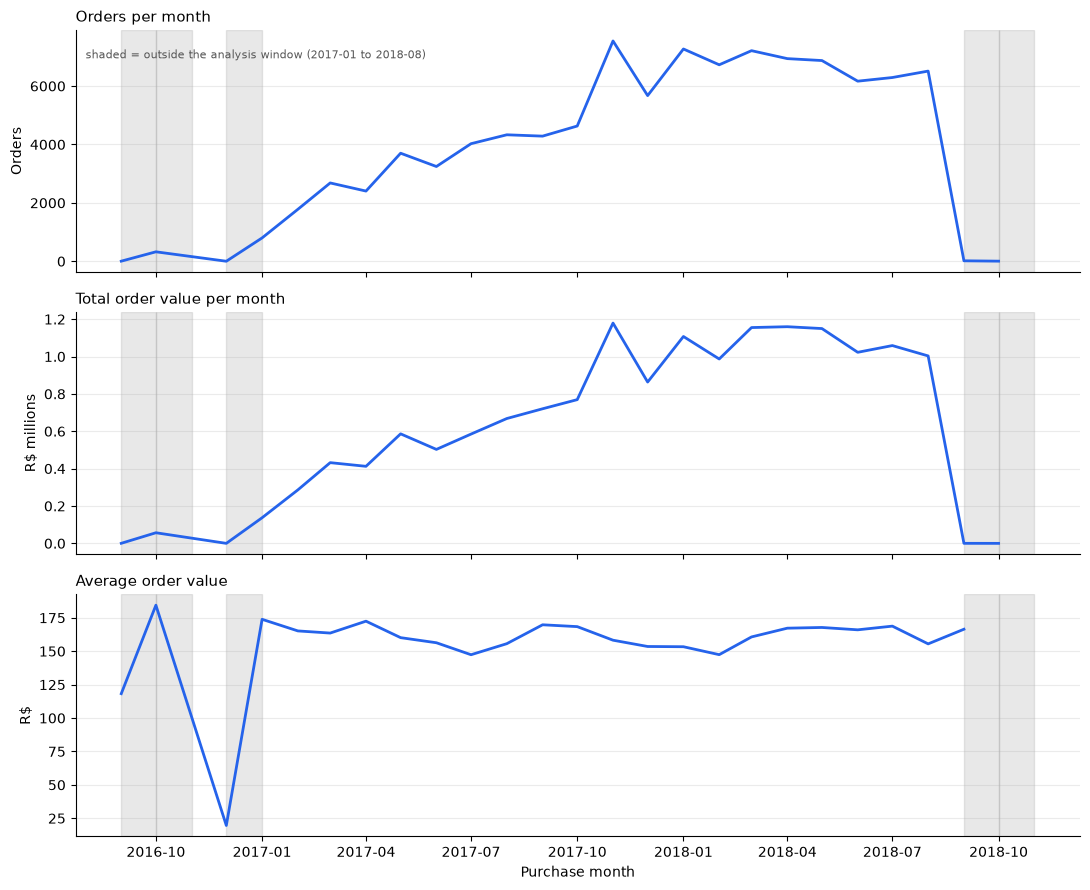

purchase_month,order_count,sparse,in_window
2016-09,4,True,False
2016-10,324,True,False
2016-12,1,True,False
2017-01,800,True,True
2018-09,16,True,False
2018-10,4,True,False


threshold: 20% of the median month (4,285) = 857 orders
window 2017-01 to 2018-08: 20 months, 99,092 orders (99.6% of all orders)


In [32]:
# A month with very few orders is not comparable with a normal one. The 20%-of-median rule
# flags candidates; the window itself is chosen by hand, because one flagged month is worth
# keeping and the rule has no way to know that.
threshold = 0.20 * monthly["order_count"].median()
monthly["sparse"] = monthly["order_count"] < threshold

analysis_start = pd.Period("2017-01", freq="M")
analysis_end   = pd.Period("2018-08", freq="M")
monthly["in_window"] = monthly["purchase_month"].between(analysis_start, analysis_end)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
panels = [("order_count",     "Orders per month",            "Orders",      1),
          ("total_value",     "Total order value per month", "R$ millions", 1e6),
          ("avg_order_value", "Average order value",         "R$",          1)]

for ax, (col, title, ylabel, scale) in zip(axes, panels):
    ax.plot(monthly["month_ts"], monthly[col] / scale, lw=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    for _, r in monthly.loc[~monthly["in_window"]].iterrows():
        ax.axvspan(r["month_ts"], (r["purchase_month"] + 1).to_timestamp(),
                   color="grey", alpha=0.18, zorder=0)


axes[0].text(0.01, 0.92,
             f"shaded = outside the analysis window ({analysis_start} to {analysis_end})",
             transform=axes[0].transAxes, fontsize=8, va="top", color="#555")
axes[-1].set_xlabel("Purchase month")
plt.show()

display(monthly.loc[monthly["sparse"] | ~monthly["in_window"],
                    ["purchase_month", "order_count", "sparse", "in_window"]]
        .style.format({"order_count": "{:,}"}).hide(axis="index"))

kept = monthly.loc[monthly["in_window"], "order_count"].sum()
print(f"threshold: 20% of the median month ({monthly['order_count'].median():,.0f}) "
      f"= {threshold:,.0f} orders")
print(f"window {analysis_start} to {analysis_end}: {int(monthly['in_window'].sum())} months, "
      f"{kept:,} orders ({kept / monthly['order_count'].sum():.1%} of all orders)")


The full range runs 2016-09 to 2018-10, but only part of it is usable.

- 2016 barely exists. September has 4 orders, December has 1, and November produced none at
  all — that month is absent from the data rather than showing as a zero.
- The last two months are a collection cut-off rather than a fall in demand: 16 orders in
  2018-09 and 4 in 2018-10.
- 2017-01 is the borderline case. Its 800 orders fall just under the 857 threshold, but it is
  kept — it sits continuously with the growth series and is 2.5 times the largest 2016 month,
  so it reads as a real trading month rather than a fragment.

That leaves 2017-01 to 2018-08: twenty months holding 99.6% of all orders. Pooling the full
range instead would let three near-empty months distort every monthly average, so month-level
results are reported inside this window only.


### Growth: more orders, or bigger baskets?


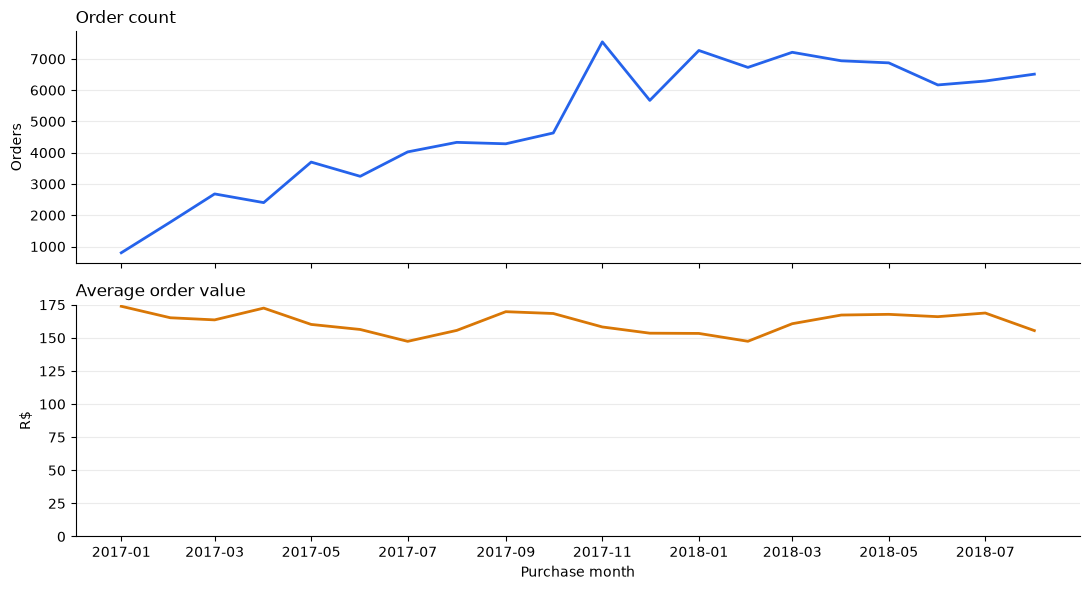

order count   800 in 2017-01 -> 6,512 in 2018-08  (8.1x), peaking at 7,544 in 2017-11
order value   R$173.88 -> R$155.50  (-10.6%), range R$147.39 to R$173.88


In [37]:
monthly_trim = monthly.loc[monthly["in_window"]].copy()
base = monthly_trim.iloc[0]
last = monthly_trim.iloc[-1]
peak = monthly_trim.loc[monthly_trim["order_count"].idxmax()]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(monthly_trim["month_ts"], monthly_trim["order_count"], lw=2)
axes[0].set_title("Order count")
axes[0].set_ylabel("Orders")

axes[1].plot(monthly_trim["month_ts"], monthly_trim["avg_order_value"], lw=2, color=AMBER)
axes[1].set_title("Average order value")
axes[1].set_ylabel("R$")
axes[1].set_ylim(0, None)

axes[-1].set_xlabel("Purchase month")
plt.show()

print(f"order count   {int(base['order_count']):,} in {base['purchase_month']} -> "
      f"{int(last['order_count']):,} in {last['purchase_month']}  "
      f"({last['order_count'] / base['order_count']:.1f}x), peaking at "
      f"{int(peak['order_count']):,} in {peak['purchase_month']}")
print(f"order value   R${base['avg_order_value']:.2f} -> R${last['avg_order_value']:.2f}  "
      f"({last['avg_order_value'] / base['avg_order_value'] - 1:+.1%}), range "
      f"R${monthly_trim['avg_order_value'].min():.2f} to "
      f"R${monthly_trim['avg_order_value'].max():.2f}")


Volume grew roughly eightfold and then levelled off. Orders run from 800 in 2017-01 to a peak
of 7,544 in 2017-11, then hold between 6,167 and 7,269 through 2018 — a growth phase followed
by a flat year. What caused the plateau is not something this data can answer.

The growth came from winning more orders, not larger ones. Order count runs 8.1 times higher by
2018-08 while average order value falls from R$173.88 to R$155.50, down about 11%, staying
inside a R$147–174 band throughout. The two levers moved independently: volume scaled eightfold
without pulling order value up with it.

November 2017 stands out — 7,544 orders and R$1.18m, consistent with Black Friday. The window
holds only one November, so this is a single observation rather than evidence of seasonality.


### Orders by day of week


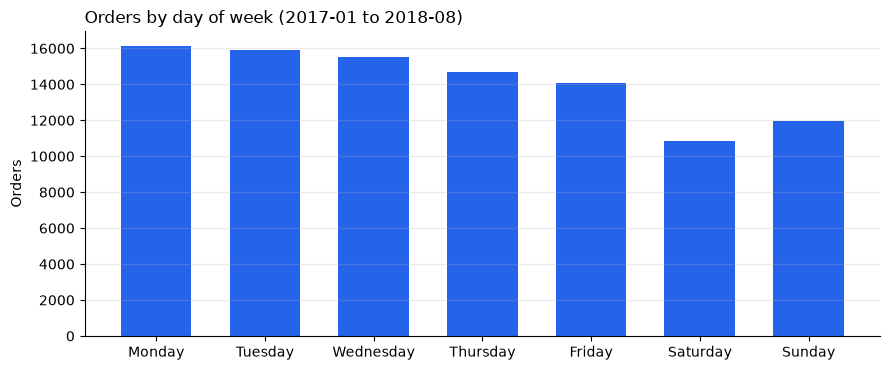

weekday,orders,pct
Monday,"16,141",16.29
Tuesday,"15,896",16.04
Wednesday,"15,501",15.64
Thursday,"14,704",14.84
Friday,"14,075",14.20
Saturday,"10,843",10.94
Sunday,"11,932",12.04


Monday to Friday: 77.0% of orders, against 71.4% if days were equal
busiest is Monday at 16,141, quietest is Saturday at 10,843 (1.49x)


In [38]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
in_window = ol["purchase_month"].between(analysis_start, analysis_end)
wd = ol.loc[in_window, "purchase_weekday"].value_counts().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(wd.index, wd.values, width=0.65)
ax.set_title(f"Orders by day of week ({analysis_start} to {analysis_end})")
ax.set_ylabel("Orders")
plt.show()

by_day = wd.reset_index()
by_day.columns = ["weekday", "orders"]
by_day["pct"] = 100 * by_day["orders"] / by_day["orders"].sum()
display(by_day.style.format({"orders": "{:,}", "pct": "{:.2f}"}).hide(axis="index"))

weekday_share = wd.loc["Monday":"Friday"].sum() / wd.sum()
print(f"Monday to Friday: {weekday_share:.1%} of orders, against {5/7:.1%} if days were equal")
print(f"busiest is {wd.idxmax()} at {wd.max():,}, quietest is {wd.idxmin()} at {wd.min():,} "
      f"({wd.max() / wd.min():.2f}x)")


Purchasing skews to weekdays and peaks on Monday. Orders decline steadily from 16,141 on Monday
to 14,075 on Friday, trough at 10,843 on Saturday, then recover to 11,932 on Sunday. Monday to
Friday accounts for 77.0% of orders against the 71.4% you would expect if every day were equal,
and the busiest day runs about 1.5 times the quietest.

The Saturday trough with a Sunday recovery suggests weekend browsing that converts early in the
following week, though nothing here tests that. Counts are restricted to the trimmed window so
the near-empty months cannot distort them.


### Category mix over time


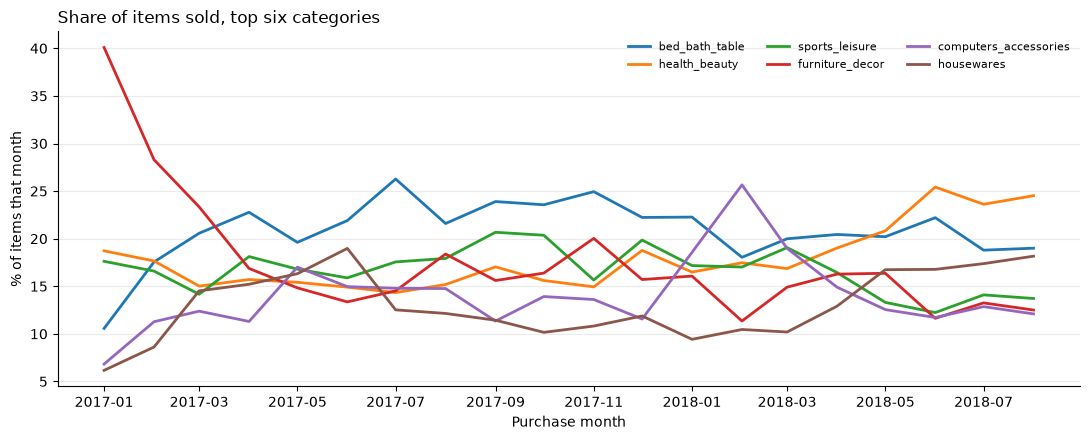

measure,first,last,change
median item price,66.90,69.99,+4.6%
median order freight,18.00,18.31,+1.7%
mean items per order,1.21,1.12,-7.2%


In [39]:
im = item_level.merge(ol[["order_id", "purchase_month"]], on="order_id")
im = im[im["purchase_month"].between(analysis_start, analysis_end)]

top6 = im["product_category_name_english"].value_counts().head(6).index
mix = (im[im["product_category_name_english"].isin(top6)]
       .groupby(["purchase_month", "product_category_name_english"]).size()
       .unstack(fill_value=0))
mix_share = 100 * mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_prop_cycle(color=plt.get_cmap("tab10").colors[:len(top6)])  # house cycle only holds 3
for cat in top6:
    ax.plot(mix_share.index.to_timestamp(), mix_share[cat], lw=2, label=cat)
ax.set_title("Share of items sold, top six categories")
ax.set_ylabel("% of items that month")
ax.set_xlabel("Purchase month")
ax.legend(frameon=False, fontsize=8, ncol=3)
plt.show()

# Average order value fell over the window. Price, freight or basket size - which moved?
w = ol.loc[ol["purchase_month"].between(analysis_start, analysis_end)]
parts = pd.DataFrame({
    "median item price":    im.groupby("purchase_month")["price"].median(),
    "median order freight": w.groupby("purchase_month")["order_freight_value"].median(),
    "mean items per order": im.groupby(["purchase_month", "order_id"]).size()
                              .groupby("purchase_month").mean(),
})
change = pd.DataFrame({"measure": parts.columns,
                       "first":  parts.iloc[0].values,
                       "last":   parts.iloc[-1].values,
                       "change": parts.iloc[-1].values / parts.iloc[0].values - 1})
display(change.style.format({"first": "{:.2f}", "last": "{:.2f}", "change": "{:+.1%}"})
        .hide(axis="index"))


The fall in average order value is not a price effect. Across the window the median item price
actually rises slightly, from R$66.90 to R$69.99, and median order freight barely moves at
R$18.00 to R$18.31. What falls is basket size: mean items per order drops from 1.21 to 1.12,
about 7%, which broadly accounts for the 11% decline in average order value.

Growth brought more orders, each marginally smaller, rather than cheaper goods. The category
mix chart says the same thing from another angle — the top six categories hold roughly steady
shares throughout, so the decline is not a shift toward cheaper categories either.


## 6. Distributions

### Order value

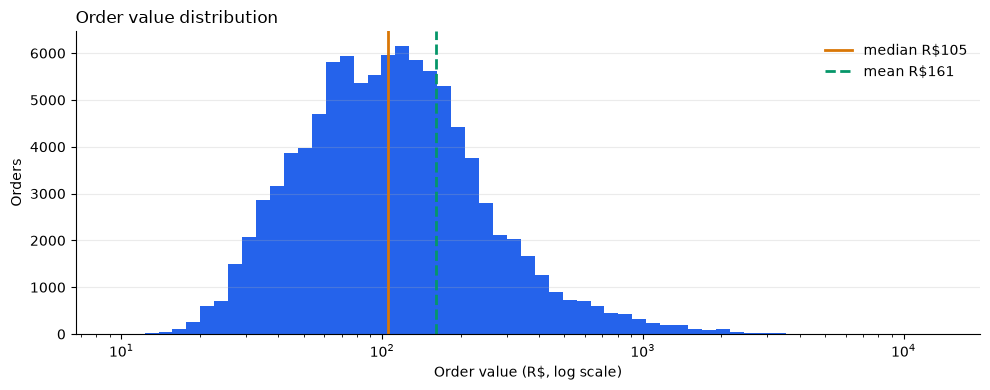

98,666 orders carry a value
median R$105.29   mean R$160.58   max R$13,664.08
  p  75  R$   176.87
  p  90  R$   307.69
  p  95  R$   450.53
  p  99  R$ 1,063.32
4.3% of orders exceed R$500; the largest 1% hold 10.4% of all value


In [40]:
value = ol["order_total_value"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(value, bins=np.logspace(np.log10(value.min()), np.log10(value.max()), 60))
ax.set_xscale("log")
ax.axvline(value.median(), color=AMBER, lw=2, label=f"median R${value.median():,.0f}")
ax.axvline(value.mean(), color=GREEN, lw=2, ls="--", label=f"mean R${value.mean():,.0f}")
ax.set_title("Order value distribution")
ax.set_xlabel("Order value (R$, log scale)")
ax.set_ylabel("Orders")
ax.legend(frameon=False)
plt.show()

print(f"{len(value):,} orders carry a value")
print(f"median R${value.median():,.2f}   mean R${value.mean():,.2f}   max R${value.max():,.2f}")
for p, x in value.quantile([0.75, 0.90, 0.95, 0.99]).items():
    print(f"  p{p*100:>4.0f}  R${x:>9,.2f}")
top1 = value.nlargest(int(len(value) * 0.01)).sum() / value.sum()
print(f"{(value > 500).mean():.1%} of orders exceed R$500; the largest 1% hold {top1:.1%} of all value")


Order value is strongly right-skewed. Half of all orders sit below R$105, the largest is
R$13,664, and the mean of R$161 sits well above the median because a small number of very large
orders pull it up — the top 1% of orders hold 10.4% of the total value on their own.

The axis is logarithmic out of necessity rather than preference. On a linear axis with the same
number of bins, 85% of orders fall into a single bar and half the chart is empty, so the shape
of the distribution cannot be seen at all. Clipping the range would fix that but would hide
around a thousand real orders, which Section 4's outlier policy rules out. The trade-off is
that a log axis renders a skewed variable as a roughly symmetric hump, so the skew is better
read from the quantiles printed below than from the shape of the bars.

That gap between mean and median is why medians are reported alongside or instead of means
throughout the rest of the notebook.


### Customers and repeat purchasing


In [41]:
customer_level = (
    ol.groupby("customer_unique_id")
      .agg(order_count = ("order_id",          "count"),
           total_spend = ("order_total_value", "sum"))
      .reset_index()
)
customer_level["is_repeat"] = customer_level["order_count"] > 1

print(f"orders                      {len(ol):,}")
print(f"distinct customer_id        {ol['customer_id'].nunique():,}   (one per order)")
print(f"distinct customer_unique_id {len(customer_level):,}   (one per person)")
print()

dist = customer_level["order_count"].value_counts().sort_index().reset_index()
dist.columns = ["orders placed", "customers"]
dist["pct of customers"] = 100 * dist["customers"] / dist["customers"].sum()
display(dist.style.format({"customers": "{:,}", "pct of customers": "{:.2f}"}).hide(axis="index"))

repeat_orders = customer_level.loc[customer_level["is_repeat"], "order_count"].sum()
print(f"repeat customers: {customer_level['is_repeat'].sum():,} of {len(customer_level):,} "
      f"({customer_level['is_repeat'].mean():.2%})")
print(f"they placed {repeat_orders:,} orders ({repeat_orders / len(ol):.1%} of all orders)")


orders                      99,441
distinct customer_id        99,441   (one per order)
distinct customer_unique_id 96,096   (one per person)



orders placed,customers,pct of customers
1,"93,099",96.88
2,"2,745",2.86
3,203,0.21
4,30,0.03
5,8,0.01
6,6,0.01
7,3,0.00
9,1,0.00
17,1,0.00


repeat customers: 2,997 of 96,096 (3.12%)
they placed 6,342 orders (6.4% of all orders)


Repeat purchasing is negligible. 99,441 orders come from 96,096 distinct people, and 93,099 of
them — 96.9% — ordered exactly once. Only 2,997 customers came back at all, and between them
they account for just 6.4% of orders.

This is only visible with the right key. `customer_id` has exactly 99,441 distinct values, one
per order, so counting repeat customers with it returns 0.00% as an artefact of how the column
is issued rather than as a finding. `customer_unique_id` is the only column that identifies a
person.

The consequence for Section 8 is structural rather than a matter of scoping preference.
Customer lifetime value needs a lifetime to measure, and where 96.9% of customers have exactly
one order, lifetime value collapses to that order's value — which is already fully observed.
That removes retention and CLV from the candidate list before any modelling question is asked.


### Seller concentration


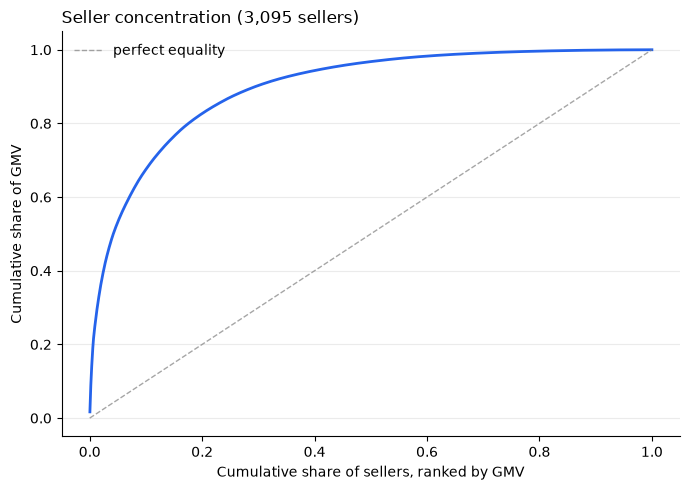

top share of sellers,share of GMV
1%,25.7%
5%,53.2%
10%,67.5%
20%,82.7%
50%,96.8%


Gini coefficient 0.792  (0 = every seller equal, 1 = one seller takes everything)
the median seller sold 8 items for R$821 in total


In [42]:
seller_level = (
    item_level.groupby("seller_id")
      .agg(items_sold = ("order_item_id", "count"),
           gmv        = ("price",         "sum"),
           state      = ("seller_state",  "first"))
      .reset_index()
)

gmv_sorted = np.sort(seller_level["gmv"].values)[::-1]
cum_share  = np.cumsum(gmv_sorted) / gmv_sorted.sum()
seller_pct = np.arange(1, len(gmv_sorted) + 1) / len(gmv_sorted)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(seller_pct, cum_share, lw=2)
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="grey", alpha=0.7, label="perfect equality")
ax.set_xlabel("Cumulative share of sellers, ranked by GMV")
ax.set_ylabel("Cumulative share of GMV")
ax.set_title(f"Seller concentration ({len(seller_level):,} sellers)")
ax.legend(frameon=False)
plt.show()

conc = pd.DataFrame({"top share of sellers": [0.01, 0.05, 0.10, 0.20, 0.50]})
conc["share of GMV"] = [cum_share[int(p * len(gmv_sorted)) - 1]
                        for p in conc["top share of sellers"]]
display(conc.style.format({"top share of sellers": "{:.0%}", "share of GMV": "{:.1%}"})
        .hide(axis="index"))

asc = np.sort(seller_level["gmv"].values)
n = len(asc)
gini = 2 * np.sum(np.arange(1, n + 1) * asc) / (n * asc.sum()) - (n + 1) / n
print(f"Gini coefficient {gini:.3f}  (0 = every seller equal, 1 = one seller takes everything)")
print(f"the median seller sold {seller_level['items_sold'].median():.0f} items "
      f"for R${seller_level['gmv'].median():,.0f} in total")


GMV is extremely concentrated. The top 1% of sellers — 31 of them — account for a quarter of
all merchandise value, the top 10% for two thirds, and the top 20% for 83%. The Gini
coefficient of 0.792 puts that in perspective: national income distributions rarely pass 0.6.

The median seller is the other half of the same picture. They sold eight items for R$821 across
the entire two-year window, which is less a business than an occasional listing.

Two things follow. Platform performance rests on a few hundred sellers, so seller risk is
concentrated in a way the headline count of 3,095 conceals completely. And per-seller rates are
unstable for most of the marketplace — with eight items to their name, a single late delivery
moves a typical seller's late rate by more than twelve points. Any seller-level analysis needs
a stated minimum-volume threshold before it means anything, which is precisely the constraint
Section 8 runs into when it assesses seller reliability as a candidate.


### Category rankings


In [43]:
cat = (
    item_level.groupby("product_category_name_english")
      .agg(items = ("order_item_id", "count"),
           gmv   = ("price",         "sum"))
      .reset_index()
)
cat["price_per_item"] = cat["gmv"] / cat["items"]
cat["rank_items"] = cat["items"].rank(ascending=False, method="min").astype(int)
cat["rank_gmv"]   = cat["gmv"].rank(ascending=False, method="min").astype(int)

cols = ["product_category_name_english", "items", "gmv", "price_per_item",
        "rank_items", "rank_gmv"]
fmt  = {"items": "{:,}", "gmv": "R${:,.0f}", "price_per_item": "R${:.2f}"}

print("Top 10 by item count")
display(cat.nlargest(10, "items")[cols].style.format(fmt).hide(axis="index"))
print("Top 10 by merchandise value")
display(cat.nlargest(10, "gmv")[cols].style.format(fmt).hide(axis="index"))

print(f"{cat['product_category_name_english'].nunique()} categories; "
      f"{item_level['product_category_name'].isna().sum():,} item rows have no category at all")


Top 10 by item count


product_category_name_english,items,gmv,price_per_item,rank_items,rank_gmv
bed_bath_table,"11,115","R$1,036,989",R$93.30,1,3
health_beauty,"9,670","R$1,258,681",R$130.16,2,1
sports_leisure,"8,641","R$988,049",R$114.34,3,4
furniture_decor,"8,334","R$729,762",R$87.56,4,6
computers_accessories,"7,827","R$911,954",R$116.51,5,5
housewares,"6,964","R$632,249",R$90.79,6,8
watches_gifts,"5,991","R$1,205,006",R$201.14,7,2
telephony,"4,545","R$323,668",R$71.21,8,14
garden_tools,"4,347","R$485,256",R$111.63,9,10
auto,"4,235","R$592,720",R$139.96,10,9


Top 10 by merchandise value


product_category_name_english,items,gmv,price_per_item,rank_items,rank_gmv
health_beauty,"9,670","R$1,258,681",R$130.16,2,1
watches_gifts,"5,991","R$1,205,006",R$201.14,7,2
bed_bath_table,"11,115","R$1,036,989",R$93.30,1,3
sports_leisure,"8,641","R$988,049",R$114.34,3,4
computers_accessories,"7,827","R$911,954",R$116.51,5,5
furniture_decor,"8,334","R$729,762",R$87.56,4,6
cool_stuff,"3,796","R$635,291",R$167.36,12,7
housewares,"6,964","R$632,249",R$90.79,6,8
auto,"4,235","R$592,720",R$139.96,10,9
garden_tools,"4,347","R$485,256",R$111.63,9,10


73 categories; 1,603 item rows have no category at all


Category rank depends entirely on whether you count items or value.

- `bed_bath_table` is 1st by items with 11,115 sold, but only 3rd by value, at R$93 an item
- `watches_gifts` is 7th by items yet 2nd by value, at R$201 an item
- `telephony` is 8th by items and 14th by value, at R$71 an item
- `health_beauty` and `computers_accessories` rank high on both

Average item price across the top categories runs from about R$71 to R$201, and that spread is
what drives the divergence. Ranking by volume overstates cheap high-turnover categories;
ranking by value overstates low-volume premium ones. Neither is wrong, but a category strategy
built on one would look quite different from one built on the other.


### Payment methods


payment_type,payments,total_value,median_value,median_inst,mean_review,pct_of_payments,pct_of_value
credit_card,"76,795","R$12,542,084",R$106.87,3,4.09,73.92,78.34
boleto,"19,784","R$2,869,361",R$93.89,1,4.09,19.04,17.92
voucher,"5,775","R$379,437",R$39.28,1,4.01,5.56,2.37
debit_card,"1,529","R$217,990",R$89.30,1,4.17,1.47,1.36
not_defined,3,R$0,R$0.00,1,1.67,0.00,0.00


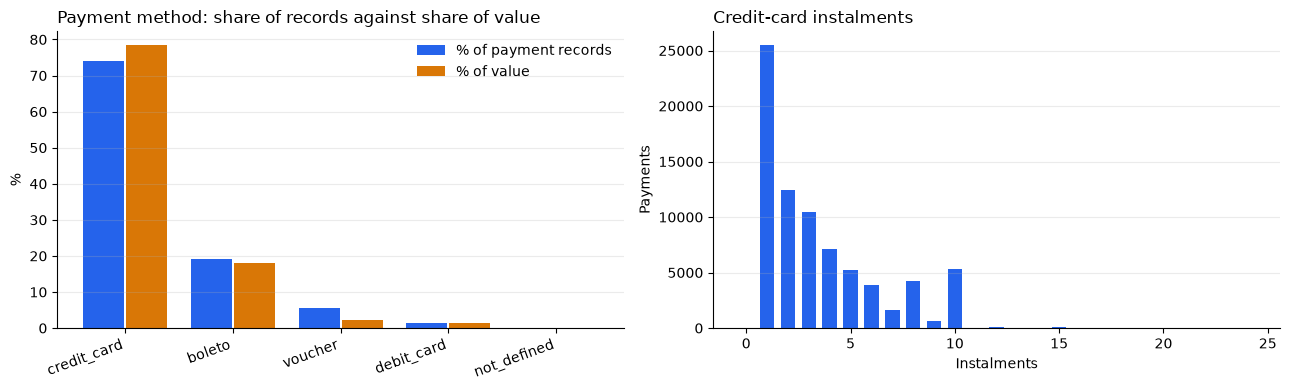

2,246 orders use more than one payment type


In [44]:
# payments holds one row per payment, so an order split across a voucher and a card appears
# twice. Shares below are shares of payment records rather than of orders, and the same
# caveat applies to mean_review.
pay = payments.merge(ol[["order_id", "review_score"]], on="order_id", how="left")

by_type = (pay.groupby("payment_type")
             .agg(payments     = ("order_id",             "size"),
                  total_value  = ("payment_value",        "sum"),
                  median_value = ("payment_value",        "median"),
                  median_inst  = ("payment_installments", "median"),
                  mean_review  = ("review_score",         "mean"))
             .sort_values("payments", ascending=False))
by_type["pct_of_payments"] = 100 * by_type["payments"] / by_type["payments"].sum()
by_type["pct_of_value"]    = 100 * by_type["total_value"] / by_type["total_value"].sum()

display(by_type.reset_index().style.format({
    "payments": "{:,}", "total_value": "R${:,.0f}", "median_value": "R${:.2f}",
    "median_inst": "{:.0f}", "mean_review": "{:.2f}",
    "pct_of_payments": "{:.2f}", "pct_of_value": "{:.2f}"}).hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(by_type))
axes[0].bar(x - 0.2, by_type["pct_of_payments"], width=0.38, label="% of payment records")
axes[0].bar(x + 0.2, by_type["pct_of_value"],    width=0.38, label="% of value")
axes[0].set_xticks(x)
axes[0].set_xticklabels(by_type.index, rotation=20, ha="right")
axes[0].set_title("Payment method: share of records against share of value")
axes[0].set_ylabel("%")
axes[0].legend(frameon=False)

inst = pay.loc[pay["payment_type"] == "credit_card", "payment_installments"].value_counts().sort_index()
axes[1].bar(inst.index, inst.values, width=0.7)
axes[1].set_title("Credit-card instalments")
axes[1].set_xlabel("Instalments")
axes[1].set_ylabel("Payments")
plt.show()

print(f"{int((payments.groupby('order_id')['payment_type'].nunique() > 1).sum()):,} orders "
      f"use more than one payment type")


Credit card dominates, and payment type says nothing about satisfaction.

- credit card — 73.9% of payment records but 78.3% of value, median R$106.87, median 3 instalments
- boleto — 19.0% of records and 17.9% of value, median R$93.89, paid in full
- voucher (5.6% / 2.4%) and debit card (1.5% / 1.4%) are marginal
- mean review score is effectively identical across all four, from 4.01 to 4.17

Credit card taking a larger share of value than of records is the instalment effect: bigger
baskets get spread over time, so the average card payment is larger. A third of card payments
are still settled in one instalment, so the option is used rather than assumed.

Two caveats. The shares count payment records, not orders — 2,246 orders are split across more
than one method, so they appear twice. And the three `not_defined` rows carry zero value; their
mean review of 1.67 is three orders' worth of noise, not a signal.


### Geography


customer_state,orders,gmv,median_order_value,median_delivery,late_rate,gmv_share
SP,"41,375","R$5,921,678",R$93.81,7,4.49,37.38
RJ,"12,762","R$2,129,682",R$112.14,12,12.10,13.44
MG,"11,544","R$1,856,161",R$108.20,10,4.58,11.72
RS,"5,432","R$885,827",R$108.41,13,6.08,5.59
PR,"4,998","R$800,935",R$105.28,10,4.04,5.06
BA,"3,358","R$611,507",R$118.13,17,12.16,3.86
SC,"3,612","R$610,214",R$110.56,13,8.20,3.85
DF,"2,125","R$353,229",R$108.20,11,5.67,2.23
GO,"2,007","R$347,707",R$113.00,14,6.54,2.19
ES,"2,025","R$324,802",R$107.78,14,10.73,2.05


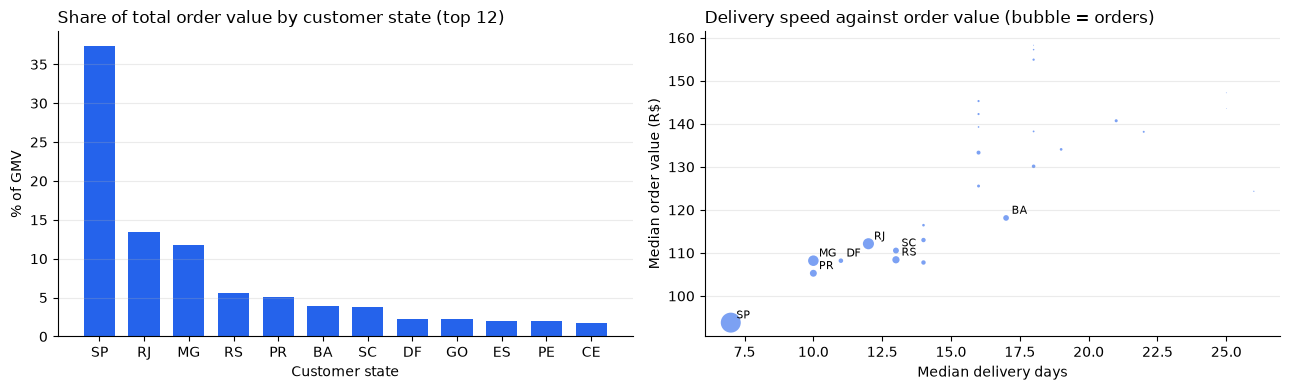

Where customers are


state,pct_of_orders
SP,41.98
RJ,12.92
MG,11.70
RS,5.50
PR,5.07


Where sellers are


state,pct_of_sellers
SP,59.74
PR,11.28
MG,7.88
SC,6.14
RJ,5.53


In [45]:
st = (ol.loc[ol["order_total_value"].notna()]
      .groupby("customer_state")
      .agg(orders             = ("order_id",           "size"),
           gmv                = ("order_total_value",  "sum"),
           median_order_value = ("order_total_value",  "median"),
           median_delivery    = ("delivery_days",      "median"),
           late_rate          = ("late_delivery_flag", "mean"))
      .sort_values("gmv", ascending=False))
st["gmv_share"] = 100 * st["gmv"] / st["gmv"].sum()
st["late_rate"] *= 100

display(st.head(12).reset_index().style.format({
    "orders": "{:,}", "gmv": "R${:,.0f}", "median_order_value": "R${:.2f}",
    "median_delivery": "{:.0f}", "late_rate": "{:.2f}", "gmv_share": "{:.2f}"})
    .hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top12 = st.head(12)
axes[0].bar(top12.index, top12["gmv_share"], width=0.7)
axes[0].set_title("Share of total order value by customer state (top 12)")
axes[0].set_xlabel("Customer state")
axes[0].set_ylabel("% of GMV")

axes[1].scatter(st["median_delivery"], st["median_order_value"],
                s=st["orders"] / 200, alpha=0.6, edgecolors="none")
for name, row in st.head(8).iterrows():
    axes[1].annotate(name, (row["median_delivery"], row["median_order_value"]),
                     fontsize=8, xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("Median delivery days")
axes[1].set_ylabel("Median order value (R$)")
axes[1].set_title("Delivery speed against order value (bubble = orders)")
plt.show()

# Moved here from the category cell, where geography did not belong.
cust = (100 * ol["customer_state"].value_counts(normalize=True).head(5)).reset_index()
cust.columns = ["state", "pct_of_orders"]
sell = (100 * seller_level["state"].value_counts(normalize=True).head(5)).reset_index()
sell.columns = ["state", "pct_of_sellers"]
print("Where customers are")
display(cust.style.format({"pct_of_orders": "{:.2f}"}).hide(axis="index"))
print("Where sellers are")
display(sell.style.format({"pct_of_sellers": "{:.2f}"}).hide(axis="index"))


Spending is concentrated in the south-east, and delivery quality broadly tracks distance.

- SP alone accounts for 41,375 orders and 37.4% of all merchandise value, with a 7-day median
  delivery and a 4.5% late rate
- RJ and MG add a further 25.2%, so three states carry 62.5% of value between them
- remote states are slower and later — CE at 18 days and 13.8% late, BA at 17 days and 12.2%

Median order value runs *inverse* to volume. SP is the lowest at R$93.81 while PE (R$133.32)
and CE (R$130.13) are the highest. Distant customers place larger orders, plausibly to justify
the freight, though nothing here establishes which way the causation runs.

Distance is not the whole story. RJ has a 12-day median delivery, close to MG's 10, yet its
late rate is 12.1% against MG's 4.6% — nearly three times higher for a similar journey. So
something beyond raw distance is at work in RJ, which this section cannot identify.

Sellers are also more concentrated than customers: SP holds 42.0% of orders but 59.7% of
sellers. That asymmetry is why most orders cross a state line, which Section 7 takes up when it
separates same-state from cross-state delivery.


## 7. Relationships and Correlation

### How early or late orders arrive 

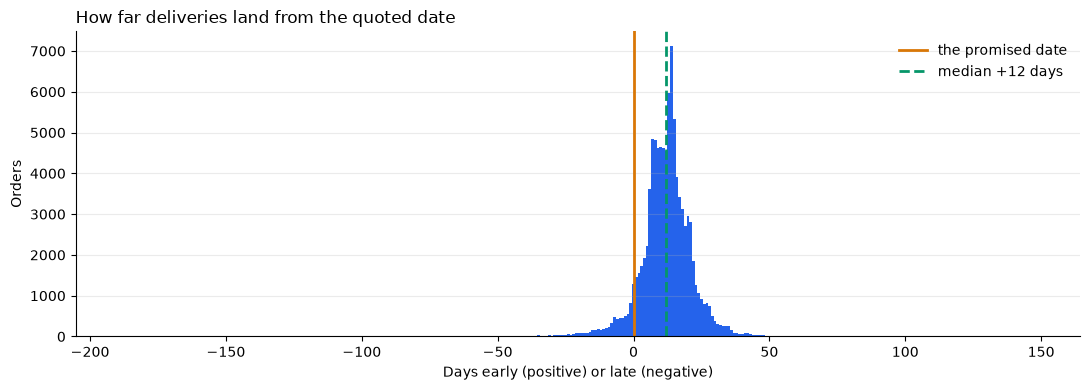

outcome,orders,pct
late,"6,534",6.77
on the promised day,"1,292",1.34
early,"88,644",91.89


median +12 days, quartiles +7 to +17, full range -188 to +147
the quote's mean absolute error is 13.3 days, of which +11.9 is systematic bias


In [46]:
# The quote is a promise; this shows how far deliveries actually land from it.
de = ol.loc[ol["is_delivered_complete"], "days_early"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(de, bins=np.arange(de.min() - 0.5, de.max() + 1.5))
ax.axvline(0, color=AMBER, lw=2, label="the promised date")
ax.axvline(de.median(), color=GREEN, lw=2, ls="--", label=f"median {de.median():+.0f} days")
ax.set_xlabel("Days early (positive) or late (negative)")
ax.set_ylabel("Orders")
ax.set_title("How far deliveries land from the quoted date")
ax.legend(frameon=False)
plt.show()

outcome = pd.DataFrame({"outcome": ["late", "on the promised day", "early"],
                        "orders":  [(de < 0).sum(), (de == 0).sum(), (de > 0).sum()]})
outcome["pct"] = 100 * outcome["orders"] / len(de)
display(outcome.style.format({"orders": "{:,}", "pct": "{:.2f}"}).hide(axis="index"))

print(f"median {de.median():+.0f} days, quartiles {de.quantile(.25):+.0f} to "
      f"{de.quantile(.75):+.0f}, full range {de.min():+.0f} to {de.max():+.0f}")
print(f"the quote's mean absolute error is {de.abs().mean():.1f} days, "
      f"of which {de.mean():+.1f} is systematic bias")


The distribution sits almost entirely on one side of the promise. 91.9% of orders arrive early,
1.3% land exactly on the quoted day, and only 6.8% are late. The median order beats its quote by
twelve days, and the middle half of all deliveries arrive between seven and seventeen days early.

That asymmetry is the finding. A quote wrong by a mean of 13.3 days, when the median delivery
itself takes only ten, is not a prediction — it is a buffer. And 11.9 of those 13.3 days are
systematic bias rather than scatter, which means most of the error could be removed by
subtracting a constant, before any per-order modelling begins.

The left tail is thin but long, reaching 188 days late. Those are the orders that matter
operationally, and Section 8 comes back to them: the cost of arriving late is not symmetric
with the benefit of arriving early.


### Delivery time and product weight


27 categories clear 500 delivered items
Slowest 8


product_category_name_english,items,median_delivery,late_rate,median_weight
office_furniture,"1,668",19,7.97,"10,912"
garden_tools,"4,268",12,6.56,"1,650"
furniture_decor,"8,160",11,7.03,"1,300"
electronics,"2,729",11,7.59,200
home_construction,596,11,5.87,900
consoles_games,"1,089",11,5.88,250
computers_accessories,"7,643",11,6.49,300
telephony,"4,430",11,6.95,225


Fastest 8


product_category_name_english,items,median_delivery,late_rate,median_weight
housewares,"6,795",9,5.00,"1,200"
luggage_accessories,"1,077",9,4.18,"1,250"
health_beauty,"9,465",9,7.56,400
home_appliances,754,9,4.51,475
small_appliances,658,9,4.56,"1,100"
pet_shop,"1,924",9,4.94,862
perfumery,"3,340",9,6.50,400
toys,"4,029",9,6.35,800


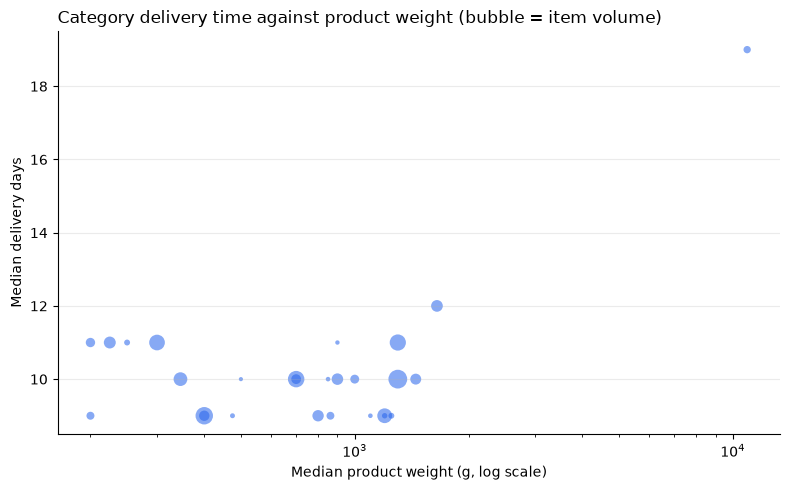

log weight vs median delivery: r = 0.54, rank correlation 0.07
with office_furniture removed: r = -0.10
median delivery spans only 9 to 19 days across all 27 categories


In [47]:
cat_del = (item_level[["order_id", "product_category_name_english", "product_weight_g"]]
           .merge(ol[["order_id", "delivery_days", "late_delivery_flag", "is_delivered_complete"]],
                  on="order_id")
           .query("is_delivered_complete"))

# 500+ items, the same minimum-volume discipline applied to sellers in Section 6.
cd = (cat_del.groupby("product_category_name_english")
        .agg(items           = ("order_id",           "size"),
             median_delivery = ("delivery_days",      "median"),
             late_rate       = ("late_delivery_flag", "mean"),
             median_weight   = ("product_weight_g",   "median"))
        .query("items >= 500")
        .sort_values("median_delivery", ascending=False))
cd["late_rate"] *= 100

fmt = {"items": "{:,}", "median_delivery": "{:.0f}", "late_rate": "{:.2f}",
       "median_weight": "{:,.0f}"}
print(f"{len(cd)} categories clear 500 delivered items")
print("Slowest 8")
display(cd.head(8).reset_index().style.format(fmt).hide(axis="index"))
print("Fastest 8")
display(cd.tail(8).reset_index().style.format(fmt).hide(axis="index"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cd["median_weight"], cd["median_delivery"], s=cd["items"] / 60,
           alpha=0.55, edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("Median product weight (g, log scale)")
ax.set_ylabel("Median delivery days")
ax.set_title("Category delivery time against product weight (bubble = item volume)")
plt.show()

# Does weight explain delivery time, or is the apparent pattern a single category?
lw       = np.log10(cd["median_weight"])
heaviest = cd["median_weight"].idxmax()
print(f"log weight vs median delivery: r = {np.corrcoef(lw, cd['median_delivery'])[0, 1]:.2f}, "
      f"rank correlation {np.corrcoef(lw.rank(), cd['median_delivery'].rank())[0, 1]:.2f}")
print(f"with {heaviest} removed: r = "
      f"{np.corrcoef(lw.drop(heaviest), cd['median_delivery'].drop(heaviest))[0, 1]:.2f}")
print(f"median delivery spans only {cd['median_delivery'].min():.0f} to "
      f"{cd['median_delivery'].max():.0f} days across all {len(cd)} categories")


Category is a weak lever on delivery time. Across the 27 categories with enough volume to
measure, median delivery spans only 9 to 19 days — and the 19 is `office_furniture` alone, with
every other category sitting between 9 and 12. Late rates are similarly compressed, running
from 4.2% to 8.0%. Geography moves the number far more: states range from 7 to 18 days, and the
same-state against cross-state split is 6 days against 12.

The scatter looks like it shows weight driving delivery time. It does not. The correlation
between log median weight and median delivery is 0.54, which sounds meaningful until you notice
that `office_furniture` is simultaneously the heaviest category and the slowest one. Remove it
and the correlation inverts to −0.10. The rank correlation across all 27 categories is 0.07,
meaning the order of categories by weight tells you almost nothing about their order by speed.

This is worth stating plainly, because the chart invites the opposite conclusion. Heavy goods
plausibly do take longer, but only one category here is heavy enough for it to show, so the
apparent trend rests on a single point. For Section 8 the practical reading is that product
attributes are weaker predictors of delivery time than geography, and a model leaning on them
would be fitting one category rather than a mechanism.


### Correlation overview


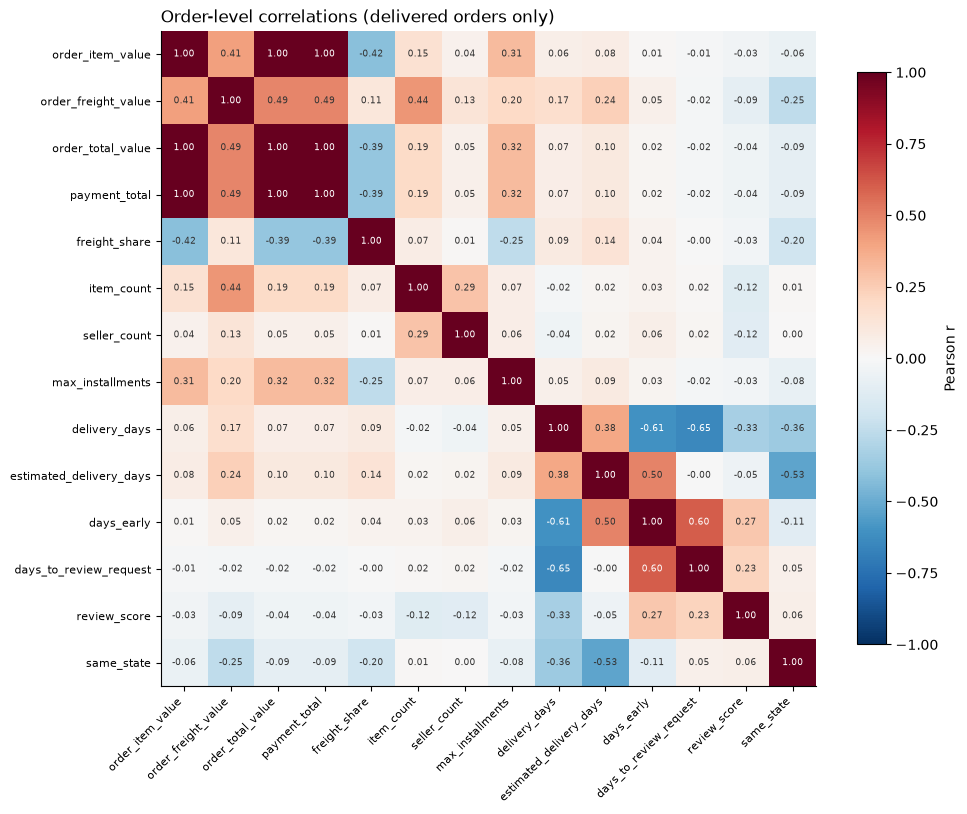

redundant: order_item_value and order_total_value  r = 0.9960
redundant: order_item_value and payment_total  r = 0.9959
redundant: order_total_value and payment_total  r = 1.0000


In [49]:
import itertools

corr_cols = ["order_item_value", "order_freight_value", "order_total_value", "payment_total",
             "freight_share", "item_count", "seller_count", "max_installments",
             "delivery_days", "estimated_delivery_days", "days_early",
             "days_to_review_request", "review_score", "same_state"]

d = ol.loc[ol["is_delivered_complete"]].copy()
d["same_state"] = d["same_state"].astype(float)      # boolean columns are dropped by .corr()
corr = d[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8.5))
ax.grid(False)                      # the house rcParams enable gridlines; a heatmap wants none
img = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.55 else "#333")
fig.colorbar(img, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Order-level correlations (delivered orders only)")
plt.show()

# Columns that are effectively the same variable, which matters for any model built later.
pairs = [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(corr.columns, 2)
         if abs(corr.loc[a, b]) >= 0.95]
for a, b, v in pairs:
    print(f"redundant: {a} and {b}  r = {v:.4f}")


Three readings matter here.

Delivery timing is the only thing that moves review scores. `delivery_days` correlates −0.33
with `review_score` and `days_early` +0.27, while every monetary variable sits between −0.03
and −0.12. What an order cost, how it was paid for, and how many items it held tell you almost
nothing about how it was rated.

Several columns are the same variable under different names. `order_total_value` and
`payment_total` correlate at exactly 1.0000, and `order_item_value` at 0.996. Any model built
later should carry one of the three rather than all of them, or it will be feeding the same
number in three times.

`days_early` is partly a measure of the quote rather than of the delivery. It correlates +0.50
with `estimated_delivery_days` and −0.61 with `delivery_days`, which follows directly from its
definition as the difference between them. An order can therefore look very early because it
was quoted generously rather than because it arrived quickly — a distinction Section 8 has to
keep in view when it picks a target.

Two smaller things. `same_state` correlates −0.53 with `estimated_delivery_days`, so Olist's
own quote already encodes distance; whatever replaces it is competing against a baseline that
is not naive. And `days_to_review_request` correlates −0.65 with `delivery_days`, which should
not happen if the request simply follows delivery. The next cell takes that apart.


### Delivery timing and review scores


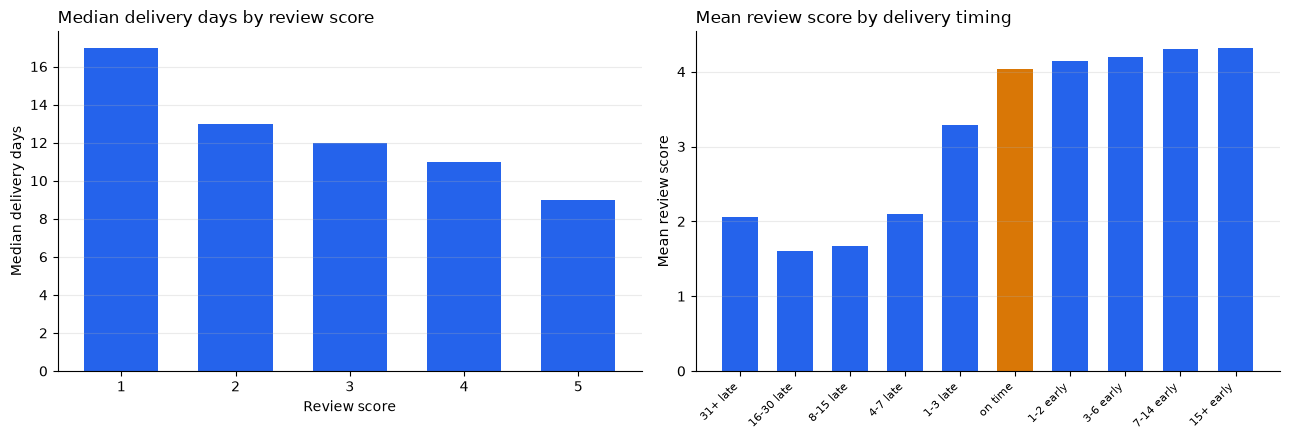

delay_bucket,mean,size
31+ late,2.06,329
16-30 late,1.60,851
8-15 late,1.67,"1,601"
4-7 late,2.10,"1,748"
1-3 late,3.29,"1,852"
on time,4.03,"1,280"
1-2 early,4.14,"2,990"
3-6 early,4.19,"9,429"
7-14 early,4.30,"40,973"
15+ early,4.32,"34,771"


In [52]:
d = ol.loc[ol["is_delivered_complete"] & ol["review_score"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_score = d.groupby("review_score")["delivery_days"].median()
axes[0].bar(by_score.index.astype(int), by_score.values, width=0.65)
axes[0].set_title("Median delivery days by review score")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("Median delivery days")

# right=False makes each bucket half-open so days_early == 0 gets its own bar. With the
# default right=True the interval (-3, 0] files on-time orders under "late".
bins   = [-np.inf, -30, -15, -7, -3, 0, 1, 3, 7, 15, np.inf]
labels = ["31+ late", "16-30 late", "8-15 late", "4-7 late", "1-3 late",
          "on time", "1-2 early", "3-6 early", "7-14 early", "15+ early"]
d["delay_bucket"] = pd.cut(d["days_early"], bins=bins, labels=labels, right=False)

by_bucket = d.groupby("delay_bucket", observed=True)["review_score"].agg(["mean", "size"])
axes[1].bar(range(len(by_bucket)), by_bucket["mean"], width=0.65,
            color=[AMBER if b == "on time" else BLUE for b in by_bucket.index])
axes[1].set_xticks(range(len(by_bucket)))
axes[1].set_xticklabels(by_bucket.index, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Mean review score by delivery timing")
axes[1].set_ylabel("Mean review score")
plt.show()

display(by_bucket.reset_index().style.format({"mean": "{:.2f}", "size": "{:,}"})
        .hide(axis="index"))


Delivery timing is the only variable that moves review scores, and it moves them sharply.
Median delivery runs 17 days for one-star orders down to 9 for five-star — close to twice as
long at the bottom as at the top.

The relationship is a cliff rather than a gradient, and the cliff is at zero. An order arriving
on the promised day averages 4.03. One that misses by a single day averages 3.29, and by four to
seven days, 2.10. Three quarters of a star is lost on the first day of lateness alone.

Arriving early buys almost nothing. Fifteen or more days early averages 4.32 against 4.30 for
seven to fourteen days and 4.19 for three to six. The curve is flat from roughly a week of slack
onward, so buffer beyond that is spent for no return at all.

Two cautions. The 31+ late bucket averages 2.06, higher than the 1.60 and 1.67 immediately
above it, which breaks the monotonic pattern — but at 329 orders it is by far the smallest
bucket and reads as noise. And the buckets are very unevenly populated: 79% of all orders sit
in the two rightmost bars, so the left-hand side of the chart rests on comparatively few
observations.

The operational reading is that the objective is asymmetric. Missing the quoted date is
expensive from the first day, while beating it stops paying after about a week. Any measure
treating a day early and a day late as equivalent — mean absolute error, for instance — hides
both effects at once.


### When the review request goes out


In [59]:
# The correlation matrix showed request timing depends on delivery speed. It should not, if
# the request simply follows delivery - so split it by how the delivery actually went.
rev = ol.loc[ol["is_delivered_complete"] & ol["days_to_review_request"].notna()]

bands = [
    ("more than 7 days late", rev["days_early"] < -7),
    ("1 to 7 days late",      rev["days_early"].between(-7, -1)),
    ("on the promised day",   rev["days_early"] == 0),
    ("early",                 rev["days_early"] > 0),
]
timing = pd.DataFrame([
    {"delivery outcome": label,
     "orders": int(mask.sum()),
     "median gap (days)": rev.loc[mask, "days_to_review_request"].median(),
     "pct asked before delivery": 100 * (rev.loc[mask, "days_to_review_request"] < 0).mean()}
    for label, mask in bands
])
display(timing.style.format({"orders": "{:,}", "median gap (days)": "{:.0f}",
                             "pct asked before delivery": "{:.1f}"}).hide(axis="index"))

late_gap = rev.loc[rev["days_early"] < 0, "days_to_review_request"]
print(f"{rev['days_to_review_request'].between(-1, 1).mean():.1%} of requests go out within a "
      f"day of delivery")
print(f"among late orders, {(late_gap < 0).mean():.1%} are asked before the parcel arrives")


delivery outcome,orders,median gap (days),pct asked before delivery
more than 7 days late,"2,781",-12,100.0
1 to 7 days late,"3,600",-1,54.8
on the promised day,"1,280",1,0.6
early,"88,163",1,0.2


92.9% of requests go out within a day of delivery
among late orders, 74.5% are asked before the parcel arrives


The review request is not triggered by delivery. For orders that arrive on time or early it
looks as though it is — the request goes out a day afterwards, for 92.9% of all orders. But for
late orders the pattern inverts: three quarters are asked to review before the parcel reaches
them, and for orders more than a week late it is every single one, a median of twelve days
early.

The request appears to fire on a schedule tied to the promised date rather than the actual one.
That has a direct consequence for Section 8. C2 proposes flagging orders for service follow-up
*before the review request goes out*, and for the orders most likely to score badly, that window
has already closed by the time delivery happens. Acting before the request on a late order means
knowing in advance that it will be late — which is C1's prediction problem, not a separate one.


### Where delivery time goes


189 of 96,470 delivered orders carry an impossible stage duration and are excluded (0.20%)


outcome,handling_days,transit_days,total
On time or early,2.15,6.95,9.10
Late,3.50,26.20,29.70


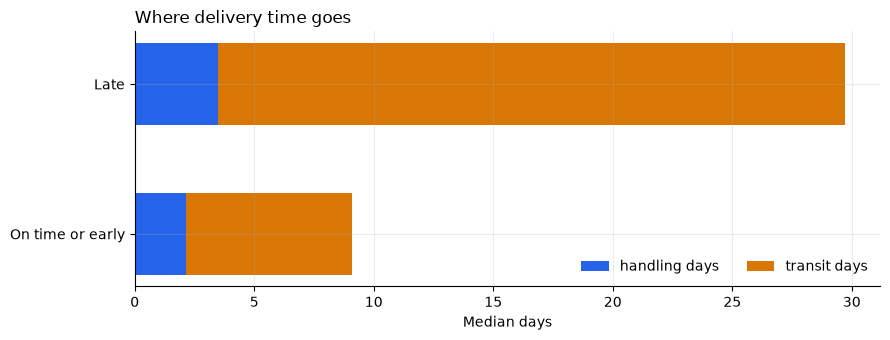

a late order takes 20.6 extra days: 19.3 in carrier transit and 1.3 in seller handling
transit accounts for 93% of the difference


In [53]:
# Section 3's Check 8 settled the definition: seller handling runs from purchase rather than
# from payment approval, because approval timestamps are often written after the parcel has
# already moved. Orders with an impossible duration under that definition are excluded here.
lc = ol.loc[ol["is_delivered_complete"]].copy()

to_days = lambda a, b: (lc[a] - lc[b]).dt.total_seconds() / 86400
lc["handling_days"] = to_days("order_delivered_carrier_date",  "order_purchase_timestamp")
lc["transit_days"]  = to_days("order_delivered_customer_date", "order_delivered_carrier_date")

usable = lc["handling_days"].ge(0) & lc["transit_days"].ge(0)
print(f"{(~usable).sum():,} of {len(lc):,} delivered orders carry an impossible stage duration "
      f"and are excluded ({1 - usable.mean():.2%})")
lc = lc.loc[usable]

stages  = ["handling_days", "transit_days"]
by_late = lc.groupby(lc["days_early"] < 0)[stages].median()
by_late.index = ["On time or early", "Late"]
by_late["total"] = by_late.sum(axis=1)
display(by_late.reset_index(names="outcome")
        .style.format("{:.2f}", subset=stages + ["total"]).hide(axis="index"))

fig, ax = plt.subplots(figsize=(9, 3.5))
bottom = np.zeros(2)
for stage in stages:
    ax.barh(by_late.index, by_late[stage], left=bottom,
            label=stage.replace("_", " "), height=0.55)
    bottom += by_late[stage].values
ax.set_xlabel("Median days")
ax.set_title("Where delivery time goes")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="x")          # barh wants vertical gridlines, not the house default
plt.show()

gap = by_late.loc["Late"] - by_late.loc["On time or early"]
print(f"a late order takes {gap['total']:.1f} extra days: {gap['transit_days']:.1f} in carrier "
      f"transit and {gap['handling_days']:.1f} in seller handling")
print(f"transit accounts for {gap['transit_days'] / gap['total']:.0%} of the difference")


Lateness happens after the parcel leaves the seller. A late order takes 20.6 more days than an
on-time one, and 19.2 of those — 93% — are carrier transit. Seller handling contributes 1.3
days, rising from a median of 2.15 to 3.50.

The asymmetry is stark. Transit time nearly quadruples on late orders, from 6.95 days to 26.20,
while handling grows by about 60%. Whatever goes wrong, it goes wrong after collection.

That weakens the case for treating seller reliability as a modelling problem. If only 7% of the
extra delay is attributable to the seller, a seller-level late rate is largely measuring which
carrier routes their parcels happen to take — a function of where a seller is rather than how
they operate. Section 8 comes back to this.

The 189 excluded orders are the ones Check 8 identified: a carrier date before the purchase, or
a delivery before collection. At 0.20% of delivered orders they could not move a median, and
every figure here is a median in any case.


### Same-state and cross-state delivery


In [54]:
# seller_state, n_seller_states and same_state live on order_level now, so this no longer
# rebuilds them from item_level.
geo = ol.loc[ol["is_delivered_complete"] & ol["seller_state"].notna()]

summary = (geo.groupby("same_state")
             .agg(orders          = ("order_id",            "size"),
                  median_delivery = ("delivery_days",       "median"),
                  late_rate       = ("late_delivery_flag",  "mean"),
                  mean_review     = ("review_score",        "mean"),
                  median_freight  = ("order_freight_value", "median"))
             .reset_index())
summary["late_rate"] *= 100
summary["same_state"] = summary["same_state"].map({False: "Cross-state", True: "Same state"})
display(summary.style.format({"orders": "{:,}", "median_delivery": "{:.0f}",
                              "late_rate": "{:.2f}", "mean_review": "{:.2f}",
                              "median_freight": "R${:.2f}"}).hide(axis="index"))

print(f"{int((geo['n_seller_states'] > 1).sum()):,} of {len(geo):,} orders involve sellers in "
      f"more than one state, so treating each order as having one seller location is safe")


same_state,orders,median_delivery,late_rate,mean_review,median_freight
Cross-state,"61,769",13,8.05,4.10,R$19.04
Same state,"34,701",7,4.50,4.26,R$12.70


509 of 96,470 orders involve sellers in more than one state, so treating each order as having one seller location is safe


Distance is the mechanism behind most of the delivery variation. An order whose seller sits in
the customer's own state takes a median of 7 days and misses its date 4.5% of the time. One
crossing a state line takes 13 days and is late 8.1% — nearly twice as long, and nearly twice as
likely to break the promise. Freight follows the same pattern, R$12.70 against R$19.04.

Most orders cross a line. 61,769 of the 96,470 delivered orders, or 64%, have the seller in a
different state from the customer. That follows directly from the concentration Section 6 found:
SP holds 42% of customers but 60% of sellers, so most of the country is buying from São Paulo.

The review gap is the interesting column, precisely because it is small. Same-state orders
average 4.26 against 4.10 cross-state — a difference of 0.16, set against the 0.74 that a single
day of lateness costs. Geography does not seem to bother customers directly. It bothers them
through the delivery time it produces, which is a useful distinction: the lever is the timing,
not the distance.

Only 509 orders involve sellers in more than one state, so treating an order as having a single
seller location holds for 99.5% of them.


### Price, freight and geography


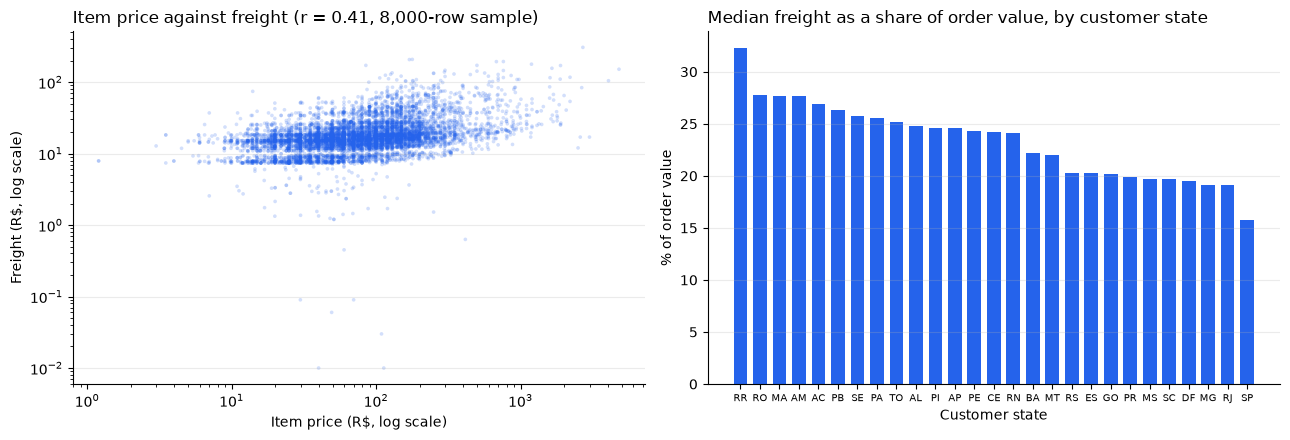

Freight share by state, highest and lowest five


customer_state,median_share,orders
RR,32.3,46
RO,27.8,253
MA,27.7,747
AM,27.7,148
AC,26.9,81
SC,19.7,"3,637"
DF,19.5,"2,140"
MG,19.2,"11,635"
RJ,19.1,"12,852"
SP,15.8,"41,746"


Freight burden by category, highest and lowest five


product_category_name_english,median_share,items
electronics,38.4,"2,767"
telephony,30.2,"4,545"
home_appliances,23.6,771
garden_tools,22.8,"4,347"
housewares,22.5,"6,964"
small_appliances,15.7,679
perfumery,14.6,"3,419"
musical_instruments,14.6,680
cool_stuff,13.5,"3,796"
watches_gifts,10.3,"5,991"


In [55]:
r_pf   = item_level[["price", "freight_value"]].corr().iloc[0, 1]
sample = item_level.sample(n=8000, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Log axes because both variables are heavily right-skewed; on linear axes almost every
# point collapses into the bottom-left corner.
axes[0].scatter(sample["price"], sample["freight_value"], s=7, alpha=0.20, edgecolors="none")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Item price (R$, log scale)")
axes[0].set_ylabel("Freight (R$, log scale)")
axes[0].set_title(f"Item price against freight (r = {r_pf:.2f}, 8,000-row sample)")

by_state = (ol.groupby("customer_state")["freight_share"]
              .agg(median_share="median", orders="size")
              .sort_values("median_share", ascending=False))
by_state["median_share"] *= 100

axes[1].bar(by_state.index, by_state["median_share"], width=0.7)
axes[1].set_title("Median freight as a share of order value, by customer state")
axes[1].set_xlabel("Customer state")
axes[1].set_ylabel("% of order value")
axes[1].tick_params(axis="x", labelsize=7)
plt.show()

print("Freight share by state, highest and lowest five")
display(pd.concat([by_state.head(5), by_state.tail(5)]).reset_index()
        .style.format({"median_share": "{:.1f}", "orders": "{:,}"}).hide(axis="index"))

# 500+ items, the same minimum-volume discipline used for sellers in Section 6.
cat_freight = (item_level.groupby("product_category_name_english")
                 .agg(median_share=("item_freight_share", "median"),
                      items=("order_item_id", "count"))
                 .query("items >= 500")
                 .sort_values("median_share", ascending=False))
cat_freight["median_share"] *= 100

print("Freight burden by category, highest and lowest five")
display(pd.concat([cat_freight.head(5), cat_freight.tail(5)]).reset_index()
        .style.format({"median_share": "{:.1f}", "items": "{:,}"}).hide(axis="index"))


Freight is a geographic cost, not a function of what you bought. Price and freight correlate at
only r = 0.41 at item level, and the state pattern is much stronger than the price one: median
freight runs from 32.3% of order value in Roraima to 15.8% in São Paulo, roughly doubling across
the country.

Category matters too, but through bulk rather than value. Electronics carry 38.4% and telephony
30.2%, while watches and gifts carry 10.3% — small, light, expensive items dilute the freight
share simply by being worth more per gram.

One caution on the state chart. The highest bars rest on very few orders: Roraima has 46 orders
in the whole dataset and Acre 81, against São Paulo's 41,746. The ordering at the top is real
but the precise percentages are not stable, and the same minimum-volume discipline applied to
sellers and categories would exclude them.


### Instalments and order value



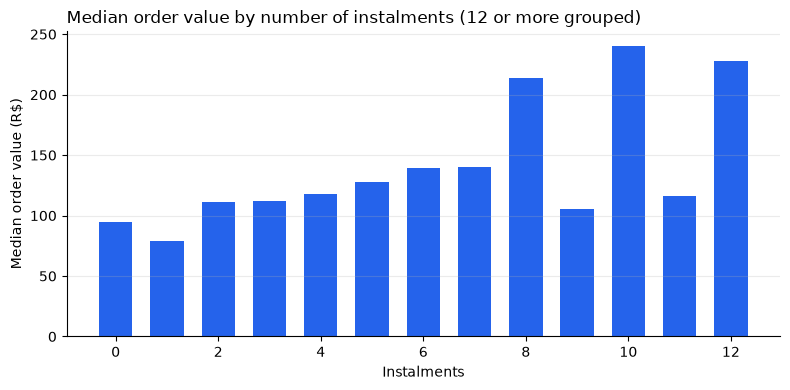

inst_bucket,median,orders
0,R$94.31,2
1,R$79.33,"48,268"
2,R$111.28,"12,363"
3,R$112.32,"10,429"
4,R$117.85,"7,070"
5,R$127.42,"5,227"
6,R$139.15,"3,908"
7,R$140.07,"1,622"
8,R$213.54,"4,251"
9,R$105.08,644


In [56]:
inst = (ol.loc[ol["max_installments"].notna()]
          .assign(inst_bucket=lambda d: d["max_installments"].clip(upper=12))
          .groupby("inst_bucket")["order_total_value"].agg(median="median", orders="size"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(inst.index.astype(int), inst["median"], width=0.65)
ax.set_title("Median order value by number of instalments (12 or more grouped)")
ax.set_xlabel("Instalments")
ax.set_ylabel("Median order value (R$)")
plt.show()

display(inst.reset_index().style.format({"inst_bucket": "{:.0f}", "median": "R${:.2f}",
                                         "orders": "{:,}"}).hide(axis="index"))


Bigger orders get spread over more payments, which is unsurprising but worth confirming. Median
order value climbs from R$79 at a single payment to R$240 at ten, roughly tripling.

The climb is not smooth, and every exception is thinly populated. Nine instalments shows R$105
across 644 orders and eleven shows R$117 across just 23, both well below their neighbours. With
48,268 orders at a single payment against 23 at eleven, the right-hand end of the chart rests on
very little. Two orders record zero instalments, which reads as a data quirk rather than a real
category.

Nothing here bears on delivery or satisfaction. It is included because instalment count is one
of the few behavioural fields available at checkout, and it is useful to know that what it
carries is information about basket size rather than about anything else.


### Does the delivery effect survive within states?



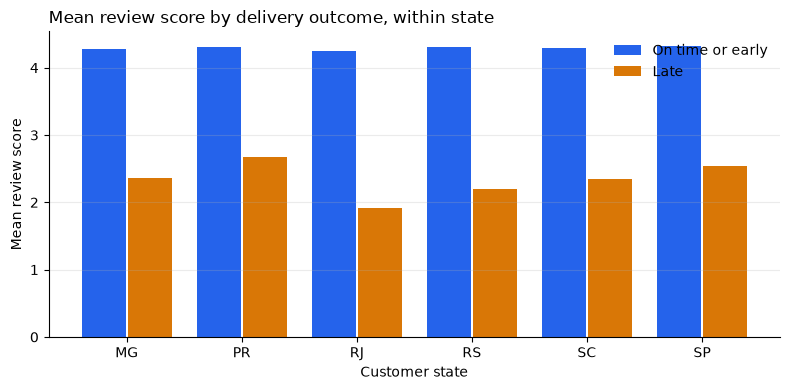

customer_state,on time or early,late,gap
MG,4.28,2.36,1.92
PR,4.30,2.68,1.63
RJ,4.24,1.91,2.33
RS,4.31,2.21,2.11
SC,4.29,2.35,1.94
SP,4.32,2.55,1.78


overall gap between on-time and late orders: 2.02 stars


In [57]:
d = ol.loc[ol["is_delivered_complete"] & ol["review_score"].notna()]
top_states = d["customer_state"].value_counts().head(6).index
sub = d.loc[d["customer_state"].isin(top_states)]

pivot = (sub.groupby(["customer_state", sub["late_delivery_flag"] == 1])["review_score"]
            .mean().unstack())
pivot.columns = ["on time or early", "late"]
pivot["gap"] = pivot["on time or early"] - pivot["late"]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pivot))
ax.bar(x - 0.2, pivot["on time or early"], width=0.38, label="On time or early")
ax.bar(x + 0.2, pivot["late"],             width=0.38, label="Late")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_title("Mean review score by delivery outcome, within state")
ax.set_xlabel("Customer state")
ax.set_ylabel("Mean review score")
ax.legend(frameon=False)
plt.show()

display(pivot.reset_index().style.format({"on time or early": "{:.2f}", "late": "{:.2f}",
                                          "gap": "{:.2f}"}).hide(axis="index"))
overall = (d.loc[d["late_delivery_flag"] == 0, "review_score"].mean()
           - d.loc[d["late_delivery_flag"] == 1, "review_score"].mean())
print(f"overall gap between on-time and late orders: {overall:.2f} stars")


The delivery effect is not geography in disguise. Within each of the six largest states, late
orders score between 1.63 and 2.33 stars below on-time ones, and the overall gap is 2.02 stars.
São Paulo delivers fastest and dominates the data, yet the gap inside São Paulo alone is 1.78 —
so the relationship is not an artefact of fast states happening to have happier customers.

The on-time column is the striking part. It barely moves: 4.24 to 4.32 across six states that
differ substantially in distance, freight cost and median delivery time. Whatever varies between
these states, it does not change how a customer rates an order that arrived when promised. All
of the variation sits on the late side, where scores run from 1.91 in Rio de Janeiro to 2.68 in
Paraná.

Rio de Janeiro is worth noting twice over. Section 6 found it has an unexpectedly high late rate
for its distance, and here it also has the harshest response to being late. Whatever is going
wrong there is going wrong on both counts.

This is the strongest evidence in the section that timing is the mechanism rather than a
correlate of one. It does not eliminate every confound — category, seller behaviour and order
composition are uncontrolled — but it removes the most obvious.


### Seller reliability


425 of 2,970 sellers have 50 or more delivered orders (14.3%), and they cover 75.6% of all seller-order rows


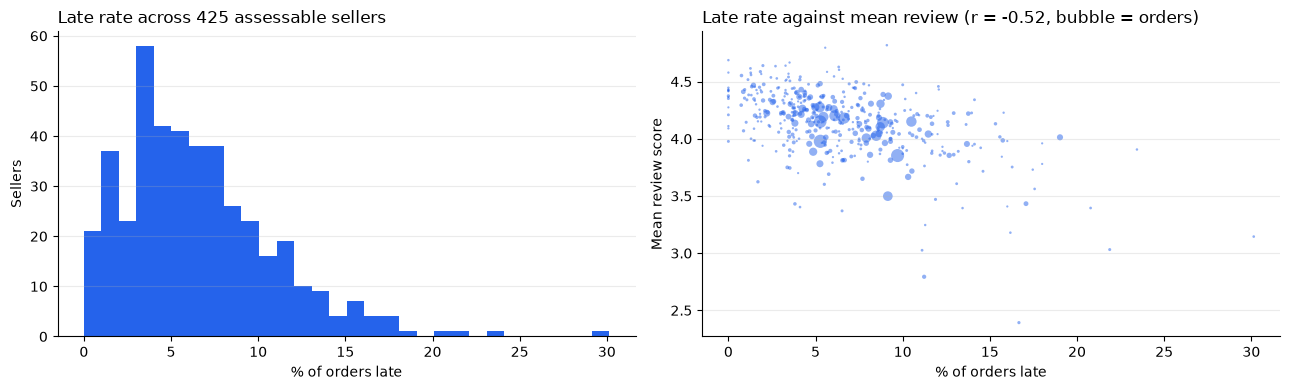

state,sellers,median_late,min_late,max_late
SP,284,6.56,0.00,23.44
RJ,16,6.49,0.00,12.15
PR,38,4.57,0.00,30.14
MG,40,4.39,0.00,15.79
SC,23,3.66,0.00,20.78
RS,11,2.38,0.00,5.45


late rate against share shipped in-state: r = 0.14


In [58]:
seller_orders = (item_level[["seller_id", "order_id"]].drop_duplicates()
                 .merge(ol[["order_id", "delivery_days", "late_delivery_flag", "review_score",
                            "is_delivered_complete", "same_state", "seller_state"]],
                        on="order_id")
                 .query("is_delivered_complete"))

# 50+ delivered orders, so a single late delivery cannot move a seller's rate by more than 2 points.
sp = (seller_orders.groupby("seller_id")
      .agg(orders          = ("order_id",           "size"),
           median_delivery = ("delivery_days",      "median"),
           late_rate       = ("late_delivery_flag", "mean"),
           mean_review     = ("review_score",       "mean"),
           pct_same_state  = ("same_state",         "mean"),
           state           = ("seller_state",       "first"))
      .query("orders >= 50"))
sp["late_rate"] *= 100
sp["pct_same_state"] *= 100

print(f"{len(sp):,} of {seller_orders['seller_id'].nunique():,} sellers have 50 or more "
      f"delivered orders ({len(sp) / seller_orders['seller_id'].nunique():.1%}), and they cover "
      f"{sp['orders'].sum() / len(seller_orders):.1%} of all seller-order rows")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sp["late_rate"], bins=30)
axes[0].set_title(f"Late rate across {len(sp)} assessable sellers")
axes[0].set_xlabel("% of orders late")
axes[0].set_ylabel("Sellers")

axes[1].scatter(sp["late_rate"], sp["mean_review"], s=sp["orders"] / 20,
                alpha=0.5, edgecolors="none")
axes[1].set_title(f"Late rate against mean review "
                  f"(r = {sp['late_rate'].corr(sp['mean_review']):.2f}, bubble = orders)")
axes[1].set_xlabel("% of orders late")
axes[1].set_ylabel("Mean review score")
plt.show()

# If late rate mostly reflected location, the spread should collapse inside a single state.
by_state = (sp.groupby("state")
              .agg(sellers=("late_rate", "size"), median_late=("late_rate", "median"),
                   min_late=("late_rate", "min"), max_late=("late_rate", "max"))
              .query("sellers >= 10").sort_values("median_late", ascending=False))
display(by_state.reset_index().style.format({"sellers": "{:,}", "median_late": "{:.2f}",
                                             "min_late": "{:.2f}", "max_late": "{:.2f}"})
        .hide(axis="index"))

print(f"late rate against share shipped in-state: r = "
      f"{sp['late_rate'].corr(sp['pct_same_state']):.2f}")


Only 425 of 2,970 sellers have the 50 delivered orders needed for a stable rate — 14.3% of the
marketplace. But those sellers handle 75.6% of all orders, so the unmeasurable majority is a long
tail of occasional listings rather than a large blind spot in the business.

Among the sellers that can be measured, late rates run from 0% to 30.1% with a median of 5.7%.
That is a wide spread for something largely outside a seller's control, given that 93% of the
extra delay on a late order is carrier transit.

Location does not explain it. If a seller's late rate mostly reflected where they are, the spread
should collapse once the state is held fixed — and it does not. The 284 assessable São Paulo
sellers still range from 0% to 23.4%, with a standard deviation of 4.13 against 4.33 for the
whole country. Between-state medians span about four points; inside São Paulo alone the range is
twenty-three. The correlation between a seller's late rate and how much they ship within their
own state is only 0.14.

It also shows up in satisfaction. Seller late rate correlates −0.52 with mean review score, a
far stronger relationship than any monetary variable manages.

This bears directly on Section 8, which downgrades seller reliability partly on the grounds that
a seller late rate "mostly measures where that seller is". The evidence here does not support
that. The volume constraint is real — three quarters of sellers cannot be scored at all — but the
location objection does not survive the test.


### What Section 7 establishes

Delivery timing is the only variable that meaningfully moves review scores, and the penalty
starts the moment the quoted date is missed rather than after a few days of grace. The mechanism
is carrier transit rather than seller handling, and it acts through timing rather than through
distance itself. All of this is association: the within-state check removes the most obvious
confound, but category, seller behaviour and order composition remain uncontrolled.


## 8. Candidate Problem Exploration

Preliminary assessment to inform Phase 2 scoping — narrowing the field with evidence, not
committing to one problem.

Seven candidates: three named at framing before any data was examined (delivery duration, low
review scores, freight cost), three emerged from Sections 5–7 (seller reliability, quote
calibration, fulfilment failure), and one — retention / CLV — rejected outright on the 3.12%
repeat rate from Section 6. Each is assessed on the same checklist: decision supported, grain,
target, data, leakage, feasibility, rejection grounds.

In [74]:
d = ol[ol["is_delivered_complete"]]
r = d[d["review_score"].notna()]

print("=== C1: delivery duration @ checkout ===")
print(f"  rows {len(d):,} | median {d['delivery_days'].median():.0f}d | incumbent quote {d['estimated_delivery_days'].median():.0f}d")
print(f"  incumbent MAE {d['days_early'].abs().mean():.1f}d | bias {d['days_early'].mean():+.1f}d")

print("\n=== C2: review_score <= 2 @ post-delivery ===")
print(f"  rows {len(r):,} | base rate {(r['review_score'] <= 2).mean():.2%} | n_positive {(r['review_score'] <= 2).sum():,}")

print("\n=== C3: freight @ checkout ===")
print(f"  items {len(item_level):,} | zero-freight {(item_level['freight_value'] == 0).mean():.2%}")

print("\n=== C4: seller reliability ===")
print(f"  sellers >= 50 orders: {len(sp):,} of {seller_orders['seller_id'].nunique():,} ({len(sp)/seller_orders['seller_id'].nunique():.1%})")
print(f"  seller late rate spread: {sp['late_rate'].min():.1f}% - {sp['late_rate'].max():.1f}%")

print("\n=== C6: fulfilment failure ===")
print(f"  no-item orders {ol['item_count'].isna().sum():,} | unavailable {(ol['order_status']=='unavailable').sum():,} | canceled {(ol['order_status']=='canceled').sum():,}")



=== C1: delivery duration @ checkout ===
  rows 96,470 | median 10d | incumbent quote 23d
  incumbent MAE 12.5d | bias +10.9d

=== C2: review_score <= 2 @ post-delivery ===
  rows 95,824 | base rate 12.81% | n_positive 12,272

=== C3: freight @ checkout ===
  items 112,650 | zero-freight 0.34%

=== C4: seller reliability ===
  sellers >= 50 orders: 425 of 2,970 (14.3%)
  seller late rate spread: 0.0% - 30.1%

=== C6: fulfilment failure ===
  no-item orders 775 | unavailable 609 | canceled 625


**Reading the evidence.**

**C1 — the incumbent is beatable, and predictably so.** MAE **12.5 days** against a median
actual delivery of 10: the quote is wrong by more than the delivery takes. Bias **+10.9 days**,
so ~87% of the error is systematic over-quoting, much of it correctable by a constant offset
before any per-order modelling. Whether the padding is error or deliberate under-promise is not
answerable here.

**C2 — base rate 12.81%**, not the 14.7% across all reviews: delivered-only drops undelivered
and cancelled orders, which score badly. 12,272 positives in 95,824 orders is ample, but "never
a bad review" scores 87.2% while flagging nothing.

**C3 — freight is not zero-inflated.** Only **0.34%** ship free, so the two-stage model assumed
at framing is unnecessary. Removes a risk, not C3's real weakness — no decision it supports.

**C4 — only 14.3% of sellers are assessable.** 425 of 2,970 reach 50+ orders. Late rates span
0.0%–30.1%, but since 93% of late time is transit, much of that reflects seller *location*.

**C6 — small failure population.** 775 orders with no line items; 609 `unavailable`, 625
`canceled` (~1.4%). Modellable, but the data records that an order failed, not why.

### Candidate problem assessment

Seven candidates, each assessed against a fixed checklist.

#### C1 — Delivery duration, predicted at checkout  ★ strongest

| Criterion | Assessment |
|---|---|
| Decision | How many days to quote at checkout. Platform operations act on it, every order. |
| Grain | One row per delivered order; 96,470 available. |
| Target | `delivery_days` — continuous, right-skewed (median 10, mean 12.1). |
| Data | Strong. Customer state, seller state, same-state flag, product weight and freight are all populated and known at purchase. |
| Leakage | Containable: every field derived from the actual delivery or carrier date is banned (`days_early`, `transit_days`, `handling_days`, `order_delivered_*`). |
| Feasibility | High. Standard regression on a clean, validated table. |
| Rejection grounds | Failure to beat the incumbent quote's MAE. |

The exploration strengthened this in three ways. The incumbent is not merely imprecise but
**biased** — quotes run ~10.9 days long. The mechanism is known: distance dominates (same-state
6 days vs cross-state 12) and 93% of late-order delay is carrier transit, so the useful
predictors are geographic and available at checkout. And Section 7's threshold effect makes the
objective asymmetric — satisfaction collapses past ~3 days late but gains nothing past ~7 days
early — which argues for predicting an **interval under quantile loss** rather than a point
estimate.

#### C2 — Predicting low review scores (1–2 stars)  ★ strong second

| Criterion | Assessment |
|---|---|
| Decision | Which delivered orders to flag for service follow-up before the review request, against a fixed daily contact budget. |
| Grain | Delivered orders with a review. |
| Target | `review_score <= 2`, binary. Base rate ~12.81%. |
| Data | Good. 768 orders lack a review and are excluded. Review *text* is largely missing and in Portuguese — out of scope. |
| Leakage | Easier than C1: prediction happens after delivery, so `delivery_days` and `days_early` are legitimate features here — the same fields banned in C1. |
| Feasibility | High, given text is excluded. |
| Rejection grounds | If delivery timing explains nearly all the variance, this collapses into C1. |

Because the class is rare, accuracy is unusable — "never a bad review" scores ~87% and flags
nothing; PR-AUC and precision@k are the appropriate metrics. The analytical value is the
**residual**: which orders score poorly *despite* arriving on time. Shares most of C1's feature
engineering, so it is cheap to pursue alongside.

#### C3 — Freight cost prediction

Statistically tractable — no missing values, strong geographic signal, no leakage risk — but
weak where it matters: **no clear decision or decision-maker.** Freight is a price the seller
sets, so predicting it supports no action. Deprioritised on business grounds, not statistical ones.

#### C4 — Seller reliability and concentration  ↓ weakened by the evidence

Promising after the Lorenz curve (top 10% of sellers ≈ 67.5% of GMV), but the lifecycle
decomposition undercut it: if 93% of late-delivery time is carrier transit and only ~7% is
seller handling, a seller-level late rate mostly measures **where that seller is**, not how they
operate. Any ranking would need a within-region comparison. Compounding this, only 425 of ~3,000
sellers have the 50+ orders needed for a stable rate, so 86% of the marketplace cannot be
assessed. Retained as descriptive context, not a modelling problem.

#### C5 — Quote calibration (a reframing of C1)

Rather than predicting duration, ask how much buffer the quote should carry. Section 7 gives the
loss function empirically — nothing gained beyond ~7 days of buffer, sharp penalty past ~3 days
late. Arguably the sharper statement of the same problem and closest to the business decision.
Folded into C1 rather than treated separately.

#### C6 — Order fulfilment failure

775 orders contain no line items; 609 `unavailable` and 625 `canceled` never completed.
A legitimate binary problem with operational use, but not pursued: the failure population is
small (~1.4%) and the causes are not observable — we see *that* an order became unavailable,
not *why*.

#### Explicitly rejected — customer retention / CLV

The repeat rate is **3.12%**: 93,099 of 96,096 customers purchased exactly once. CLV requires a
lifetime to measure; where 96.9% of customers have a single order, CLV collapses to that order's
value, already fully observed. A structural property of the data, not a scoping constraint.

#### Conclusion

**C1 is the strongest candidate**, with C2 a complementary second. C1 supports a concrete
recurring decision, has ~96,000 clean rows, a well-understood leakage boundary, an identified
mechanism (distance and transit), and — decisively — a **measurable incumbent to beat**, which
makes success a number rather than a judgement.

One baseline would settle the choice: whether a model using only checkout-available features
beats the incumbent quote's MAE. If it does, C1 proceeds and C2 becomes a natural extension. If
not, C2 becomes primary, since its prediction point permits the delivery features C1 must exclude.

In [75]:
order_level.to_csv(DATA_DIR / "order_level.csv", index=False)
item_level.to_csv(DATA_DIR / "item_level.csv", index=False)
products_clean.to_csv(DATA_DIR / "products_clean.csv", index=False)
reviews_dedup.to_csv(DATA_DIR / "reviews_dedup.csv", index=False)

## 9. Key Insights and Patterns

Five findings, each traceable to a specific measurement in this notebook.

| # | Finding | Supporting evidence | Why it matters |
|---|---|---|---|
| 1 | **The delivery quote is systematically padded, not merely inaccurate.** Orders arrive a median of 11 days early. | §7. Median actual delivery 10 days vs median quote 23. Incumbent MAE 12.5 days, bias +10.9 — ~87% of the error is systematic over-quoting. | A quote wrong by more than the delivery takes is a checkout liability. Because the error is systematic, much of it is correctable by a constant offset. |
| 2 | **Satisfaction has a cliff at ~3 days late, and no upside from arriving early.** | §7. Mean review 4.01 at 0–3 days late, 2.67 at 3–7, ~1.7 beyond. 15+ days early (4.32) equals 7–15 days early (4.32). | The goal is not "deliver faster" but "do not miss the promise by more than ~3 days"; buffer beyond a week is wasted. A symmetric metric hides both effects. |
| 3 | **Late delivery is a distance and transit problem, not a seller problem.** | §7. Late orders take ~18 extra days, of which 17.0 (93%) is carrier transit and 1.3 seller handling. Same-state median 6 days vs 12 cross-state; late rates 6.06% vs 9.27%. | Identifies where intervention would work, and confirms the strongest predictors (customer state, seller state, same-state flag) are known at checkout with no leakage. |
| 4 | **Repeat purchasing is negligible: 3.12%.** | §6. 93,099 of 96,096 customers (96.9%) placed exactly one order across 25 months. | Rules out retention and CLV structurally rather than by choice. Also a data trap: `customer_id` is issued per order, so counting with it yields a 0% repeat rate. |
| 5 | **Growth came entirely from acquisition, not larger baskets — and AOV declined.** | §5. Indexed to 2017-01 = 100, order count reaches 814 by 2018-08 (peaking ~943 in 2017-11) while AOV ends at 89, ~10% below its start, holding in an R$147–174 band. | Revenue growth is an acquisition story. The two levers move independently: volume scaled 8× without dragging order value up, and the plateau suggests that phase had ended by the cut-off. |

### What the data shows versus what it suggests

**Shown.** All five are direct measurements — the delivery gap, the review distribution across
delay buckets, the lifecycle decomposition, the repeat rate, the GMV concentration — computed
from the source tables and reconciling against Section 2 row counts.

**Suggested, not shown.** That delay *causes* dissatisfaction is an association. It survives
controlling for customer state, which rules out the most obvious confound, but category, seller
behaviour and order composition are not controlled for. Similarly, the padded quotes are
consistent with a deliberate under-promise strategy, but nothing here distinguishes intent from
estimation error.

**Not addressable with this data.** Why orders become `unavailable` or `canceled`, whether the
2018 plateau is saturation or capacity, and anything requiring repeat customer behaviour.